# Comments

## To-do

- Eligible creators: Increase accuracy by considering the minimum follower count
    - Just implemented this (23-03-2026), which also led to the consideration to drop physical deals

## Dropping Physical deals motivation

**The Ultimate Goal**: To isolate and validate the predictive power of LLM-evaluated marketing copy on the number of applications a deal receives.

**Part 1: The Evidence (Why the combined model was failing)**

We initially attempted to model both Online and Physical deals in a single regression, which led to a rank-deficient design matrix and statistically insignificant physical features. We diagnosed three core issues:

- Structural Zeros & Zero-Inflation: By combining deal types, every Online deal forced a 0 into the physical distance features (e.g., log_phys_active_0_30d_10_20km). This massive block of structural zeros anchored the regression slopes, artificially exploding the standard errors and masking any true physical signal.

- Macro vs. Micro Collinearity ("Tug-of-War"): When we included market_scope (country tiers), it consumed all the variance. The model blamed poor performance on "being in Germany" rather than "having no creators within 10km."

- Sample Size & Sparsity: With only N=470 physical deals (and 341 of them clustered in the Netherlands), slicing the physical metrics into multiple time/distance bins starved the model of the degrees of freedom required to find a significant signal.

**Part 2: The Rationale (Why dropping Physical Deals is the correct move)**

To prove that "better marketing copy drives more applications," we must construct an econometric "soundproof room" that minimizes noise.

- Eradicating Unobserved Heterogeneity (Friction): For online deals, marketing copy is the primary driver of the user's decision to apply. For physical deals, unobserved real-world friction (weather, transit time, parking costs) heavily dominates the decision. If we include physical deals, that unobserved friction inflates the error term (ϵ), making it statistically nearly impossible for the subtle signal of "marketing copy quality" to cross the p<0.05 threshold.

- No Endogenous Selection Bias: Dropping physical deals does not create selection bias in the dependent variable (Y). Filtering the dataset by an exogenous feature like deal_type == 'online' is Selection on X. This simply redefines our population scope. It preserves perfect internal validity (the estimator remains consistent for online deals), even though it restricts our external validity (we cannot generalize the LLM's impact to physical deals).

- Model Stability: By looking strictly at online deals, we completely eliminate the structural zero problem, resolving the perfect multicollinearity and allowing the baseline liquidity features (log_online_active_...) to properly control for platform traffic.

In [1]:
FILTER_PHYSICAL = False

# Basic Model

In [2]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np
import re


from src import paths
# Import your factory function from your object-oriented script
from src.barter.regression_models import create_regression_runner

# Load the mathematically prepped data
df = pd.read_parquet(paths.PROCESSED_DATA_DIR /
                     'BARTER_DEALS_MODEL_READY.parquet')

# Filter to only online deals, see rationale in Comments section
if FILTER_PHYSICAL:
    df = df[df.deal_type == 'online']

## Merge content categories

In [3]:
# Ensure your date column is a datetime object first
# final_df['date_col'] = pd.to_datetime(final_df['created_at'])

# Create Year-Month (Format: "2025-01", "2025-02", etc.)
df['year_month'] = df['created_at'].dt.strftime('%Y-%m')

# Create Year-Week using ISO standard (Format: "2025-W01", "2025-W02", etc.)
# Note: %G is ISO Year and %V is ISO Week. This prevents weird bugs
# where the first week of January belongs to the last week of the previous year.
df['year_week'] = df['created_at'].dt.strftime('%G-W%V')

In [ ]:
def clean_tags(tag_set):
    # If the cell is actually just NaN (not a set), return it as is
    if pd.isna(tag_set) and not isinstance(tag_set, (set, list)):
        return np.nan

    # Keep items that are NOT 'UGC' and NOT NaN
    cleaned = {item for item in tag_set if item != 'UGC' and not pd.isna(item)}

    # If the set is now empty (e.g., it was just {'UGC'} or {'UGC', nan}), return NaN
    return cleaned if len(cleaned) > 0 else np.nan


# Apply the cleaning function
df['content_types_set'] = df['content_types_set'].apply(set)
df['content_types_clean'] = df['content_types_set'].apply(
    clean_tags)


# Define the exact word boundaries (\b) so "mother" doesn't trigger on "smother"
# WARNING: The Dutch word "kind" overlaps with the English word "kind" (e.g., "be kind to your skin").
# If you have a lot of English Beauty deals, you might want to replace '\bkind\b' with '\bkindje\b' or '\bkinderen\b' to avoid false positives.
mom_keywords = [
    r'\bbaby\b', r'\bchildren\b', r'\bkids\b', r'\bkind\b', r'\bkinderen\b',
    r'\bparents\b', r'\bvader\b', r'\bmoeder\b', r'\bfather\b', r'\bmother\b',
    r'\bouders\b', r'\btoddler\b', r'\bzwanger\b', r'\bpregnant\b'
]

# Compile the regex pattern for speed
mom_regex = re.compile('|'.join(mom_keywords), re.IGNORECASE)


def assign_macro_category(row):
    tag_set = row['content_types_set']
    deal_type = str(row.get('deal_type', 'unknown')).lower()

    # Combine title and description to search for keywords (adjust column names as needed)
    text_content = str(row.get('deal_text', '')) + " " + \
        str(row.get('description', ''))

    # Handle floats, NaNs, or empty sets
    if not isinstance(tag_set, (set, list)) or pd.isna(tag_set):
        return 'Uncategorized'

    cleaned_tags = {str(t) for t in tag_set if str(
        t).lower() not in ['ugc', 'nan', 'none']}
    if not cleaned_tags:
        return 'Uncategorized'

    # --- 1. The Validated Family & Parenting Category ---
    if 'Mom' in cleaned_tags:
        if cleaned_tags == {'Mom'}:
            return 'Family & Parenting'
        # Check if the text actually contains parenting keywords
        elif mom_regex.search(text_content):
            return 'Family & Parenting'
        else:
            # If it's a fake "Mom" deal, remove the tag so it falls into its true category below
            cleaned_tags.remove('Mom')

    # If a deal didn't have the 'Mom' tag but heavily features the keywords,
    # you can uncomment the next two lines to forcibly categorize it as Parenting:
    # elif mom_regex.search(text_content):
    #     return 'Family & Parenting'

    # If removing 'Mom' left the set empty, it's basically uncategorized
    if not cleaned_tags:
        return 'Other'

    if 'Animals' in cleaned_tags:
        return 'Animals'

    # --- 3. Split Food & Beverage Logic ---
    has_food_drink = any(tag in cleaned_tags for tag in [
                         'Food', 'Drinks', 'Vegan'])
    has_cooking = 'Cooking' in cleaned_tags

    if has_cooking or (has_food_drink and deal_type == 'online'):
        return 'Home Cooking & CPG'
    elif has_food_drink and deal_type == 'physical':
        return 'Dining & Hospitality'
    elif has_food_drink:
        return 'Food & Beverage (Unknown Type)'

    # --- 4. Beauty ---
    if 'Beauty' in cleaned_tags:
        return 'Beauty'

    # --- 5. Fashion ---
    if 'Fashion' in cleaned_tags:
        return 'Fashion'

    # --- 6. Split Entertainment & Experiences Logic ---
    ent_tags = ['Entertainment', 'Experiences', 'Nightlife',
                'Movie', 'Music', 'Travel', 'Activities', 'Photography']
    has_ent = any(tag in cleaned_tags for tag in ent_tags)

    if has_ent and deal_type == 'physical':
        return 'In-Person Experiences'
    elif has_ent and deal_type == 'online':
        return 'Digital Entertainment'
    elif has_ent:
        return 'Entertainment & Experiences (Unknown Type)'

    # --- 7. Lifestyle & Home (The Catch-all) ---
    if any(tag in cleaned_tags for tag in ['Lifestyle', 'Luxury']):
        return 'Lifestyle & Home'

        # --- 2. Tech & Male-Skewed Niche ---
    if any(tag in cleaned_tags for tag in ['Gaming', 'Tech', 'Cars', 'Finance', 'Sport']):
        return 'Tech & Niche'

    return 'Other'


# Apply the new validated function
df['macro_category'] = df.apply(assign_macro_category, axis=1)

## Models

In [ ]:
# The variables you want to test
CATEGORICALS = ['market_scope', 'consolidated_categories', 'year_week']
CATEGORICALS = ['market_scope', 'macro_category', 'year_month']
CATEGORICALS = ['market_scope', 'macro_category']


CONTINUOUS = ['competitor_density']
CONTINUOUS = ['competitor_density', 'log_online_active_0_7d', 'log_online_active_7_30d',
              'log_phys_active_0_7d_0_20km', 'log_phys_active_0_7d_20_50km']


BINARIES = ['accepts_international']
BINARIES = ['is_live']
BINARIES = ['strict_follower_requirement']
# BINARIES = []

# Experimental groups (required by your BaseRegressionRunner)
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id']


# --- 1. Test Baseline OLS ---
ols_runner = create_regression_runner(
    target_col='log_apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='ols'
)

ols_results = ols_runner.run_baseline_model(
    df=df,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="Baseline_OLS"
)

# --- 2. Test Baseline Negative Binomial ---
# NegBin requires the RAW count, not the log!
negbin_runner = create_regression_runner(
    target_col='apps_after_7_days',
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='negbin'
)

nb_results = negbin_runner.run_baseline_model(
    df=df,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="Baseline_NegBin"
)

# print(ols_results['Baseline_OLS'].summary())
display(nb_results['Baseline_NegBin'].summary())

✓ Baseline model fitted: 3126.0 observations, AIC=8749.20
✓ Baseline model fitted: 3126 observations, AIC=22454.59


<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 3126
Model:               NegativeBinomial   Df Residuals:                     3106
Method:                           MLE   Df Model:                           19
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                 0.04824
Time:                        14:11:15   Log-Likelihood:                -11206.
converged:                       True   LL-Null:                       -11774.
Covariance Type:              cluster   LLR p-value:                4.927e-229
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    2.4162      0.269      8.968      0.000       1.888       2.945
strict_follower_requirement             -0.1373      0.062     -2.205      0.028      -0.259      -0.015
competitor_density                      -0.0473      0.009     -5.113      0.000      -0.065      -0.029
log_online_active_0_7d                   1.0725      0.181      5.915      0.000       0.717       1.428
log_online_active_7_30d                 -0.8947      0.166     -5.403      0.000      -1.220      -0.570
log_phys_active_0_7d_0_20km              0.1524      0.057      2.666      0.008       0.040       0.265
log_phys_active_0_7d_20_50km             0.0439      0.058      0.753      0.452      -0.070       0.158
market_scope_Tier2_NLD_only             -0.3425      0.070     -4.896      0.000      -0.480      -0.205
market_scope_Tier3_BEL_Only             -1.0698      0.213     -5.012      0.000      -1.488      -0.651
market_scope_Tier4_Germany              -1.6510      0.080    -20.659      0.000      -1.808      -1.494
macro_category_Beauty                    0.5838      0.204      2.863      0.004       0.184       0.984
macro_category_Digital Entertainment    -0.2191      0.215     -1.020      0.308      -0.641       0.202
macro_category_Dining & Hospitality      0.1766      0.225      0.784      0.433      -0.265       0.618
macro_category_Family & Parenting       -0.0694      0.234     -0.297      0.766      -0.528       0.389
macro_category_Fashion                   0.5190      0.215      2.419      0.016       0.098       0.940
macro_category_Home Cooking & CPG        0.2714      0.199      1.363      0.173      -0.119       0.662
macro_category_In-Person Experiences    -0.3711      0.256     -1.450      0.147      -0.873       0.131
macro_category_Lifestyle & Home          0.5762      0.211      2.727      0.006       0.162       0.991
macro_category_Tech & Niche             -0.2707      0.270     -1.003      0.316      -0.801       0.259
macro_category_Uncategorized            -0.0319      0.271     -0.118      0.906      -0.564       0.500
alpha                                    0.9700      0.038     25.655      0.000       0.896       1.044
========================================================================================================
"""

In [62]:
# The variables you want to test
CATEGORICALS = ['market_scope', 'macro_category', 'year_month']
CONTINUOUS = ['competitor_density']


BINARIES = ['accepts_international']
BINARIES = ['is_live']
BINARIES = ['strict_follower_requirement']
# BINARIES = []

# Experimental groups (required by your BaseRegressionRunner)
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id']


# --- 1. Test Baseline OLS ---
ols_runner = create_regression_runner(
    target_col='log_apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='ols'
)

ols_results = ols_runner.run_baseline_model(
    df=df,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="Baseline_OLS"
)

# --- 2. Test Baseline Negative Binomial ---
# NegBin requires the RAW count, not the log!
negbin_runner = create_regression_runner(
    target_col='apps_after_7_days',
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='negbin'
)

nb_results = negbin_runner.run_baseline_model(
    df=df,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="Baseline_NegBin"
)

# print(ols_results['Baseline_OLS'].summary())
display(nb_results['Baseline_NegBin'].summary())

✓ Baseline model fitted: 3126.0 observations, AIC=8704.22
✓ Baseline model fitted: 3126 observations, AIC=22402.69


<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 3126
Model:               NegativeBinomial   Df Residuals:                     3100
Method:                           MLE   Df Model:                           25
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                 0.05095
Time:                        14:11:02   Log-Likelihood:                -11174.
converged:                       True   LL-Null:                       -11774.
Covariance Type:              cluster   LLR p-value:                1.975e-237
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                    2.5958      0.203     12.786      0.000       2.197       2.994
strict_follower_requirement             -0.1879      0.058     -3.219      0.001      -0.302      -0.073
competitor_density                      -0.0558      0.010     -5.632      0.000      -0.075      -0.036
market_scope_Tier2_NLD_only             -0.3300      0.066     -5.023      0.000      -0.459      -0.201
market_scope_Tier3_BEL_Only             -1.2081      0.182     -6.646      0.000      -1.565      -0.851
market_scope_Tier4_Germany              -1.6645      0.080    -20.878      0.000      -1.821      -1.508
macro_category_Beauty                    0.6064      0.195      3.117      0.002       0.225       0.988
macro_category_Digital Entertainment    -0.2044      0.208     -0.982      0.326      -0.613       0.204
macro_category_Dining & Hospitality      0.2537      0.198      1.283      0.200      -0.134       0.641
macro_category_Family & Parenting       -0.0560      0.224     -0.249      0.803      -0.496       0.384
macro_category_Fashion                   0.5713      0.209      2.728      0.006       0.160       0.982
macro_category_Home Cooking & CPG        0.2490      0.190      1.313      0.189      -0.123       0.621
macro_category_In-Person Experiences    -0.3229      0.236     -1.366      0.172      -0.787       0.141
macro_category_Lifestyle & Home          0.6000      0.208      2.881      0.004       0.191       1.009
macro_category_Tech & Niche             -0.2307      0.268     -0.860      0.390      -0.757       0.296
macro_category_Uncategorized            -0.0020      0.250     -0.008      0.994      -0.492       0.488
year_month_2025-06                       0.2261      0.107      2.120      0.034       0.017       0.435
year_month_2025-07                       0.4102      0.108      3.810      0.000       0.199       0.621
year_month_2025-08                       0.1053      0.121      0.870      0.385      -0.132       0.343
year_month_2025-09                       0.2186      0.110      1.994      0.046       0.004       0.434
year_month_2025-10                       0.5833      0.113      5.178      0.000       0.362       0.804
year_month_2025-11                       0.5457      0.117      4.654      0.000       0.316       0.776
year_month_2025-12                       0.5035      0.156      3.222      0.001       0.197       0.810
year_month_2026-01                       0.4432      0.125      3.554      0.000       0.199       0.688
year_month_2026-02                       0.5813      0.127      4.575      0.000       0.332       0.831
year_month_2026-03                       1.1232      0.182      6.180      0.000       0.767       1.480
alpha                                    0.9500      0.038     25.275      0.000       0.876       1.024
===========================================================================================

## Validation: MSE comparison

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Get predictions from both models
# Note: OLS predicts log(1+y), so we must exponentiate and subtract 1
ols_pred_log = ols_results['Baseline_OLS'].fittedvalues
ols_pred_raw = np.expm1(ols_pred_log)  # exp(x) - 1

# NegBin predicts raw counts natively
nb_pred_raw = nb_results['Baseline_NegBin'].fittedvalues

# 2. Get the actual raw target values
actual_raw = df['apps_after_7_days']

# 3. Calculate Mean Absolute Error (MAE)
ols_mae = mean_absolute_error(actual_raw, ols_pred_raw)
nb_mae = mean_absolute_error(actual_raw, nb_pred_raw)

print(f"OLS Mean Absolute Error: {ols_mae:.2f} applications")
print(f"NegBin Mean Absolute Error: {nb_mae:.2f} applications")

OLS Mean Absolute Error: 11.00 applications
NegBin Mean Absolute Error: 13.79 applications


# LLM Evaluations Model

In [ ]:
# Setup
import yaml
from src.analysis.engine import AnalysisEnvironment
from src.barter.regression_models import create_regression_runner
from src.utils import interactive_regression_results_selector

import pandas as pd
import numpy as np
import statsmodels.api as sm

In [46]:
env = AnalysisEnvironment(active_analysis='barter_deals')

# Load everything
final_df, og_df = env.load_data()
pm, prompt_map = env.load_prompts(prompt_subfolder='sandbox/BARTER_DEALS')

Loading files for analysis barter_deals
🐢 Running full processing pipeline...
Results dir: C:\Users\Wouter Barter\Documents\AI_thesis\results\sandbox\BARTER_DEALS
input_data_path: C:\Users\Wouter Barter\Documents\AI_thesis\data\processed\BARTER_DEALS_MODEL_READY.parquet
Loading evaluations...
⚠️ Skipping arch_temp: No .pt files found in C:\Users\Wouter Barter\Documents\AI_thesis\results\sandbox\BARTER_DEALS\arch_temp
📊 Loaded evaluations with top_k values: [500]
Finished loading experiment data
Merging input data and evaluations
Finished merging.
✅ No garbage detected. Skipping merge and returning original data.
Sorting logits...
Finished sorting logits.
Computing ratings from logits...
Found 1 different scale sizes: [np.int64(4)]
  Processed 71242 rows with scale_size=4
Finished computing ratings.
Computing entropy for 1 different scale sizes: [np.int64(4)]
  Processed 71242 rows with scale_size=4


C:\Users\Wouter Barter\Documents\AI_thesis\src\data_processing.py:570: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.loc[:, 'first_content_type'] = final_df.content_types.apply(


USE PROCESSED INPUT DATA = True
PromptManager initialized with folder: ..\prompts\PromptSuites\sandbox\BARTER_DEALS
Scanning 16 suites from ..\prompts\PromptSuites\sandbox\BARTER_DEALS...
Loaded 16 PromptSuites


## Minor crisis: Endogeneity & simultaneity through the 'nr of active creators' variable

We are trying to measure textual characteristics of deals, specifically variables related to 'deal quality', expressed through marketing copy quality. We measure 'active creators' through the number of unique creators that applied to a deal in a given time period (e.g., 7 days before the deal). This proxy captures multiple underlying effects, however: the number of active users on the platform (supply), and the quality of the deals *(demand/quality); if the quality of the deals is higher, the number of applications will be higher as well (as per our hypothesis). Because of this, any measurable effect of marketing copy quality will be soaked up by the 'nr of active creators' proxy. For this reason, we must adopt a fixed-effects approach instead, with week/month time dummies.

## Pre-processing

In [47]:
# Filter out physical deals, see Comments for rationale
if FILTER_PHYSICAL:
    final_df = final_df[final_df['deal_type'] == 'online']

In [48]:
# Ensure your date column is a datetime object first
# final_df['date_col'] = pd.to_datetime(final_df['created_at'])

# Create Year-Month (Format: "2025-01", "2025-02", etc.)
final_df['year_month'] = final_df['created_at'].dt.strftime('%Y-%m')
og_df['year_month'] = og_df['created_at'].dt.strftime('%Y-%m')


# Create Year-Week using ISO standard (Format: "2025-W01", "2025-W02", etc.)
# Note: %G is ISO Year and %V is ISO Week. This prevents weird bugs
# where the first week of January belongs to the last week of the previous year.
final_df['year_week'] = final_df['created_at'].dt.strftime('%G-W%V')
og_df['year_week'] = og_df['created_at'].dt.strftime('%G-W%V')

Balance datasets so AICs are comparable. 

In [50]:
def balance_experimental_df(df, input_id_col='input_id', group_cols=['model_name', 'prompt_id']):
    """
    Balances the dataframe so that every experimental group contains 
    the exact same set of unique input_ids. (Long-format safe)
    """
    print(f"Original rows: {len(df)}")

    # 1. Group by the experimental units and collect the set of input_ids for each
    grouped_ids = df.groupby(group_cols)[input_id_col].apply(set)

    # 2. Find the strict intersection
    common_ids = set.intersection(*grouped_ids.values)

    print(f"Unique input_ids appearing in ALL groups: {len(common_ids)}")

    # 3. Filter the dataframe
    balanced_df = df[df[input_id_col].isin(common_ids)].copy()

    # 4. Final verification (Checking UNIQUE ids, not total rows)
    id_counts = balanced_df.groupby(group_cols)[input_id_col].nunique()
    row_counts = balanced_df.groupby(group_cols).size()

    if id_counts.nunique() == 1:
        print(
            f"✅ Success! All groups now evaluate exactly {id_counts.iloc[0]} unique deals.")
        print("\nRow distribution (Formative prompts will show 3x rows due to sub-dimensions):")
        print(row_counts)
    else:
        print("⚠️ Warning: Balancing failed. Check for duplicate input_ids within groups.")
        print(id_counts)

    return balanced_df, common_ids


# --- EXECUTION ---
final_df_balanced, gold_set_ids = balance_experimental_df(final_df)

og_df_balanced = og_df[og_df['deal_id'].isin(gold_set_ids)].copy()

Original rows: 71219
Unique input_ids appearing in ALL groups: 3084
✅ Success! All groups now evaluate exactly 3084 unique deals.

Row distribution (Formative prompts will show 3x rows due to sub-dimensions):
model_name             prompt_id   
Qwen/Qwen3.5-4B        16071a84cca9    18504
                       26fac938d6ea     3084
                       5f7ea2deacb8    12336
                       d39649b54a27    18504
google/gemma-4-E2B-it  16071a84cca9    18504
dtype: int64


## Inspection

In [51]:
with open('../src/configs/config.yaml', 'r') as f:
    full_config = yaml.safe_load(f)

active_analysis = full_config['active_analysis']
model_vars = full_config['analyses'][active_analysis]['model_vars']
experimental_groups = model_vars['experimental_groups']

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. Setup & Pre-computation ---
# date_col = 'date'
# final_df[date_col] = pd.to_datetime(final_df[date_col])

# # Optional: Add a date filter here if step 1 revealed outliers
# # final_df = final_df[final_df[date_col] > '2020-01-01']

# final_df['experiment_group'] = (
#     final_df['model_name'].astype(str) + " | " +
#     final_df['dimension_name'].astype(str) + " | " +
#     final_df['prompt_id'].astype(str).str[:8]
# )

# print("Pre-computing time series matrix...")
# time_series_df = final_df.pivot_table(
#     index=pd.Grouper(key=date_col, freq='W'),
#     columns='experiment_group',
#     values='mean_rating',
#     aggfunc='mean'
# )
# print("Ready!")

# --- 1. Setup & Pre-computation ---
date_col = 'date'
final_df[date_col] = pd.to_datetime(final_df[date_col])

final_df['experiment_group'] = (
    final_df['model_name'].astype(str) + " | " +
    final_df['dimension_name'].astype(str) + " | " +
    final_df['prompt_id'].astype(str).str[:8]
)

print("Pre-computing time series matrix...")
time_series_df = final_df.pivot_table(
    index=pd.Grouper(key=date_col, freq='W'),
    columns='experiment_group',
    values='mean_rating',
    aggfunc='mean'
)

# ---> NEW ADDITION: Handle the incomplete edge effect <---
max_raw_date = final_df[date_col].max()
max_grouped_date = time_series_df.index.max()

print(f"Latest raw data timestamp: {max_raw_date}")
print(f"Latest weekly bucket ends on: {max_grouped_date}")

# If the raw data's max date is strictly less than the end boundary
# of the final weekly bucket (and ignoring timezones for simple comparison),
# it means the week did not finish.
if max_raw_date.date() < max_grouped_date.date():
    print("Dropping the final week due to incomplete data...")
    time_series_df = time_series_df.iloc[:-1]  # Drop the last row

print("Ready!")

# --- 2. Create Widgets First ---
experiment_selector = widgets.SelectMultiple(
    options=time_series_df.columns.tolist(),
    value=time_series_df.columns.tolist()[:2],
    rows=10,
    description='Experiments:',
    style={'description_width': 'initial'},
    layout={'width': '80%'}
)

# Output widget to safely capture the plot
plot_output = widgets.Output()

# --- 3. Fast Plotting Function ---


def update_plot(change=None):
    selected_experiments = experiment_selector.value

    # Send all print/plot commands to the output widget
    with plot_output:
        # Clears the old plot before drawing the new one
        clear_output(wait=True)

        if not selected_experiments:
            print("Please select at least one experiment to plot.")
            return

        fig, ax = plt.subplots(figsize=(14, 7))

        for exp in selected_experiments:
            ax.plot(time_series_df.index,
                    time_series_df[exp], label=exp, marker='o', alpha=0.8)

        ax.set_title('Mean Rating Over Time', fontsize=14, fontweight='bold')
        ax.set_xlabel('Time', fontsize=12)
        ax.set_ylabel('Mean Rating', fontsize=12)

        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
                  title="Selected Experiments")
        ax.grid(True, linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.show()

        # Explicitly close the figure to free up memory
        plt.close(fig)


# --- 4. Bind and Display ---
# Tell the selector to run 'update_plot' whenever its value changes
experiment_selector.observe(update_plot, names='value')

print("💡 Tip: Hold Ctrl (Windows) or Cmd (Mac) to select/deselect multiple lines.")
display(experiment_selector)
display(plot_output)

# Trigger the first plot manually
update_plot()

Pre-computing time series matrix...
Latest raw data timestamp: 2026-03-10 00:00:00
Latest weekly bucket ends on: 2026-03-15 00:00:00
Dropping the final week due to incomplete data...
Ready!
💡 Tip: Hold Ctrl (Windows) or Cmd (Mac) to select/deselect multiple lines.


SelectMultiple(description='Experiments:', index=(0, 1), layout=Layout(width='80%'), options=('Qwen/Qwen3.5-4B…

Output()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. Setup & Pre-computation ---
date_col = 'date'
final_df[date_col] = pd.to_datetime(final_df[date_col])

final_df['experiment_group'] = (
    final_df['model_name'].astype(str) + " | " +
    final_df['dimension_name'].astype(str) + " | " +
    final_df['prompt_id'].astype(str).str[:8]
)

print("Pre-computing time series matrices...")

# Compute both Mean and Std over time
time_series_mean = final_df.pivot_table(
    index=pd.Grouper(key=date_col, freq='W'),
    columns='experiment_group',
    values='mean_rating',
    aggfunc='mean'
)

time_series_std = final_df.pivot_table(
    index=pd.Grouper(key=date_col, freq='W'),
    columns='experiment_group',
    values='mean_rating',
    aggfunc='std'
)

# Handle the incomplete edge effect
max_raw_date = final_df[date_col].max()
max_grouped_date = time_series_mean.index.max()

if max_raw_date.date() < max_grouped_date.date():
    print("Dropping the final week due to incomplete data...")
    time_series_mean = time_series_mean.iloc[:-1]
    time_series_std = time_series_std.iloc[:-1]

# Create Min-Max scaled version of the means (0 to 1)
time_series_scaled = (time_series_mean - time_series_mean.min()) / \
    (time_series_mean.max() - time_series_mean.min())

print("Ready!")

# --- 2. Create Widgets ---
experiment_selector = widgets.SelectMultiple(
    options=time_series_mean.columns.tolist(),
    value=time_series_mean.columns.tolist()[:2],
    rows=10,
    description='Experiments:',
    style={'description_width': 'initial'},
    layout={'width': '80%'}
)

metric_selector = widgets.Dropdown(
    options=['Raw Mean Rating',
             'Min-Max Scaled Mean (0-1)', 'Standard Deviation'],
    value='Raw Mean Rating',
    description='Metric:',
    style={'description_width': 'initial'}
)

plot_output = widgets.Output()

# --- 3. Fast Plotting & Stats Function ---


def update_plot(change=None):
    selected_experiments = list(experiment_selector.value)
    selected_metric = metric_selector.value

    with plot_output:
        clear_output(wait=True)

        if not selected_experiments:
            print("⚠️ Please select at least one experiment to plot.")
            return

        # Choose the correct dataframe based on the dropdown
        if selected_metric == 'Raw Mean Rating':
            plot_df = time_series_mean[selected_experiments]
            y_label = 'Mean Rating (1-4)'
        elif selected_metric == 'Min-Max Scaled Mean (0-1)':
            plot_df = time_series_scaled[selected_experiments]
            y_label = 'Scaled Rating (0 to 1)'
        else:
            plot_df = time_series_std[selected_experiments]
            y_label = 'Standard Deviation'

        # --- DRAW PLOT ---
        fig, ax = plt.subplots(figsize=(14, 6))
        for exp in selected_experiments:
            ax.plot(plot_df.index, plot_df[exp],
                    label=exp, marker='o', alpha=0.8)

        ax.set_title(f'{selected_metric} Over Time',
                     fontsize=14, fontweight='bold')
        ax.set_xlabel('Time', fontsize=12)
        ax.set_ylabel(y_label, fontsize=12)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left',
                  title="Selected Experiments")
        ax.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
        plt.close(fig)

        # --- HARD NUMBERS: Descriptive Stats & Correlation ---
        print("\n" + "="*80)
        print("📊 HARD NUMBERS: GLOBAL DEAL-LEVEL STATISTICS")
        print("="*80)

        # Calculate global stats across all specific deals for the selected experiments
        mask = final_df['experiment_group'].isin(selected_experiments)
        global_stats = final_df[mask].groupby('experiment_group')['mean_rating'].agg(
            ['count', 'mean', 'std', 'min', 'max']
        ).round(3)
        display(global_stats)

        if len(selected_experiments) > 1:
            print("\n📈 TIME-SERIES CORRELATION MATRIX (Pearson's r on Weekly Means)")
            print("-" * 80)
            corr_matrix = time_series_mean[selected_experiments].corr().round(
                3)
            display(corr_matrix)


# --- 4. Bind and Display ---
experiment_selector.observe(update_plot, names='value')
metric_selector.observe(update_plot, names='value')

print("💡 Tip: Hold Ctrl (Windows) or Cmd (Mac) to select/deselect multiple lines.")
display(widgets.VBox([experiment_selector, metric_selector]))
display(plot_output)

# Trigger first render
update_plot()

Pre-computing time series matrices...
Dropping the final week due to incomplete data...
Ready!
💡 Tip: Hold Ctrl (Windows) or Cmd (Mac) to select/deselect multiple lines.


Output()

### Correlations

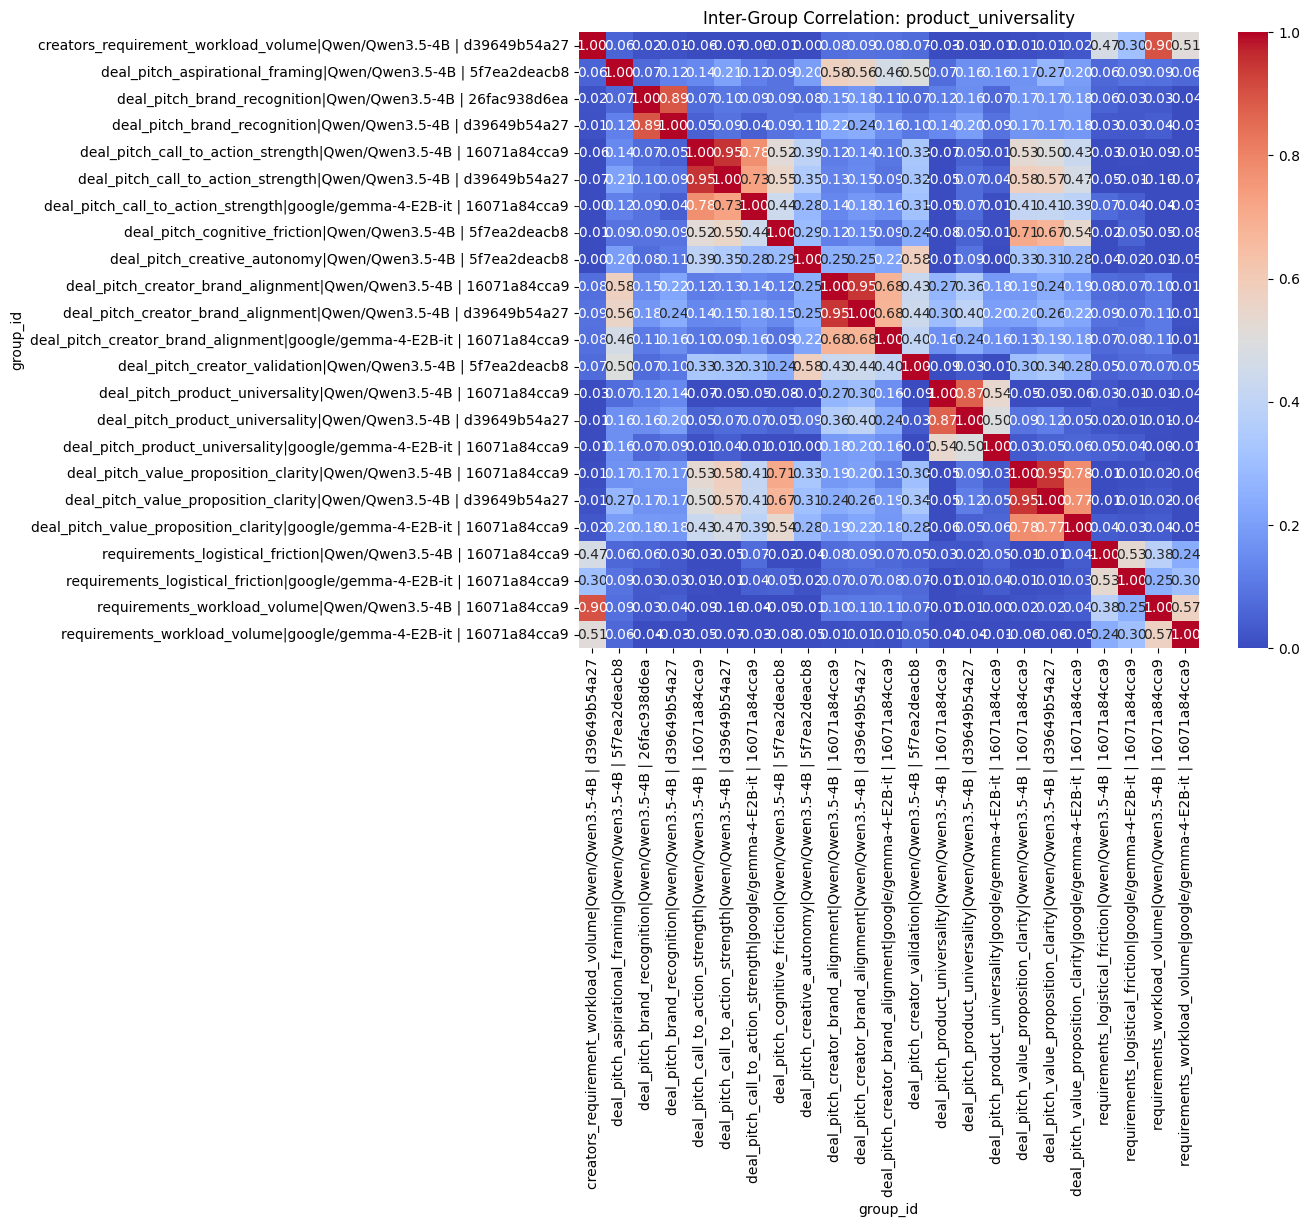

group_id,creators_requirement_workload_volume|Qwen/Qwen3.5-4B | d39649b54a27,deal_pitch_aspirational_framing|Qwen/Qwen3.5-4B | 5f7ea2deacb8,deal_pitch_brand_recognition|Qwen/Qwen3.5-4B | 26fac938d6ea,deal_pitch_brand_recognition|Qwen/Qwen3.5-4B | d39649b54a27,deal_pitch_call_to_action_strength|Qwen/Qwen3.5-4B | 16071a84cca9,deal_pitch_call_to_action_strength|Qwen/Qwen3.5-4B | d39649b54a27,deal_pitch_call_to_action_strength|google/gemma-4-E2B-it | 16071a84cca9,deal_pitch_cognitive_friction|Qwen/Qwen3.5-4B | 5f7ea2deacb8,deal_pitch_creative_autonomy|Qwen/Qwen3.5-4B | 5f7ea2deacb8,deal_pitch_creator_brand_alignment|Qwen/Qwen3.5-4B | 16071a84cca9,...,deal_pitch_product_universality|Qwen/Qwen3.5-4B | 16071a84cca9,deal_pitch_product_universality|Qwen/Qwen3.5-4B | d39649b54a27,deal_pitch_product_universality|google/gemma-4-E2B-it | 16071a84cca9,deal_pitch_value_proposition_clarity|Qwen/Qwen3.5-4B | 16071a84cca9,deal_pitch_value_proposition_clarity|Qwen/Qwen3.5-4B | d39649b54a27,deal_pitch_value_proposition_clarity|google/gemma-4-E2B-it | 16071a84cca9,requirements_logistical_friction|Qwen/Qwen3.5-4B | 16071a84cca9,requirements_logistical_friction|google/gemma-4-E2B-it | 16071a84cca9,requirements_workload_volume|Qwen/Qwen3.5-4B | 16071a84cca9,requirements_workload_volume|google/gemma-4-E2B-it | 16071a84cca9
group_id,,,,,,,,,,,,,,,,,,,,,
creators_requirement_workload_volume|Qwen/Qwen3.5-4B | d39649b54a27,1.000000,0.058147,0.016213,0.014790,-0.058954,-0.072858,-0.004541,-0.008362,0.000972,0.078648,...,-0.030475,-0.010434,-0.007572,0.005475,0.013159,0.024647,0.470484,0.304803,0.901369,0.514631
deal_pitch_aspirational_framing|Qwen/Qwen3.5-4B | 5f7ea2deacb8,0.058147,1.000000,0.069275,0.124714,0.140692,0.210792,0.124168,0.092577,0.195526,0.577131,...,0.074345,0.157332,0.158018,0.165078,0.273604,0.197852,0.063346,0.091186,0.085078,0.064298
deal_pitch_brand_recognition|Qwen/Qwen3.5-4B | 26fac938d6ea,0.016213,0.069275,1.000000,0.893253,0.072511,0.101431,0.087424,0.091142,0.077994,0.154256,...,0.119232,0.155958,0.065116,0.174239,0.169742,0.184554,0.057900,0.031582,0.028909,-0.038785
deal_pitch_brand_recognition|Qwen/Qwen3.5-4B | d39649b54a27,0.014790,0.124714,0.893253,1.000000,0.049987,0.089044,0.044165,0.091882,0.108398,0.220437,...,0.144298,0.195596,0.087711,0.173679,0.165044,0.180366,0.034662,0.029774,0.040320,-0.034972
deal_pitch_call_to_action_strength|Qwen/Qwen3.5-4B | 16071a84cca9,-0.058954,0.140692,0.072511,0.049987,1.000000,0.951795,0.776599,0.518600,0.390683,0.116385,...,-0.067390,0.053915,0.013129,0.529139,0.500708,0.432371,-0.026394,0.005826,-0.085060,-0.053356
deal_pitch_call_to_action_strength|Qwen/Qwen3.5-4B | d39649b54a27,-0.072858,0.210792,0.101431,0.089044,0.951795,1.000000,0.727963,0.552366,0.354706,0.126956,...,-0.051156,0.072905,0.041307,0.581713,0.570572,0.469148,-0.045299,-0.009833,-0.096803,-0.069175
deal_pitch_call_to_action_strength|google/gemma-4-E2B-it | 16071a84cca9,-0.004541,0.124168,0.087424,0.044165,0.776599,0.727963,1.000000,0.444347,0.280496,0.139824,...,-0.051081,0.072358,0.005739,0.413780,0.414738,0.390314,0.072948,0.044212,-0.039609,-0.030929
deal_pitch_cognitive_friction|Qwen/Qwen3.5-4B | 5f7ea2deacb8,-0.008362,0.092577,0.091142,0.091882,0.518600,0.552366,0.444347,1.000000,0.291266,0.124066,...,-0.084895,0.052411,0.005317,0.707342,0.673774,0.535197,-0.015250,0.051511,-0.047089,-0.083291
deal_pitch_creative_autonomy|Qwen/Qwen3.5-4B | 5f7ea2deacb8,0.000972,0.195526,0.077994,0.108398,0.390683,0.354706,0.280496,0.291266,1.000000,0.249668,...,-0.008395,0.089538,0.000140,0.331196,0.305910,0.279381,-0.037801,0.018764,-0.007962,-0.047139


In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def analyze_group_correlations(df, dimension="product_universality", score_col="mean_rating"):
    """
    Pivots long-form LLM data to compare experimental groups (Model + Prompt) 
    against each other for a specific dimension.
    """
    # 1. Create a unique identifier for each experimental group
    df = df.copy()
    df['group_id'] = df['dimension_name'] + "|" + \
        df['model_name'] + " | " + df['prompt_id']
    dim_df = df
    # 2. Filter for the dimension of interest
    # dim_df = df[df['dimension_name'] == dimension]

    # 3. Pivot to wide format
    # Index should be your unique deal identifier (e.g., 'deal_id' or 'id')
    # Use whatever column uniquely identifies the text being rated.
    pivot_df = dim_df.pivot_table(
        index='deal_id',
        columns='group_id',
        values=score_col
    )

    # 4. Calculate Correlation Matrix
    corr_matrix = pivot_df.corr()

    # 5. Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
                fmt=".2f", vmin=0, vmax=1)
    plt.title(f"Inter-Group Correlation: {dimension}")
    plt.show()

    return corr_matrix


# Run the analysis
corr_results = analyze_group_correlations(final_df)
corr_results

In [55]:
final_df.groupby(experimental_groups)[
    ['mean_rating', 'apps_after_7_days']].corr()

mean_rating  \
model_name            prompt_id    dimension_name                                                        
Qwen/Qwen3.5-4B       16071a84cca9 deal_pitch_call_to_action_strength   mean_rating           1.000000   
                                                                        apps_after_7_days     0.077124   
                                   deal_pitch_creator_brand_alignment   mean_rating           1.000000   
                                                                        apps_after_7_days     0.186762   
                                   deal_pitch_product_universality      mean_rating           1.000000   
                                                                        apps_after_7_days     0.177505   
                                   deal_pitch_value_proposition_clarity mean_rating           1.000000   
                                                                        apps_after_7_days     0.051530   
                                   requirements_logistical_friction     mean_rating           1.000000   
                                                                        apps_after_7_days     0.001617   
                                   requirements_workload_volume         mean_rating           1.000000   
                                                                        apps_after_7_days    -0.009038   
                      26fac938d6ea deal_pitch_brand_recognition         mean_rating           1.000000   
                                                                        apps_after_7_days     0.122348   
                      5f7ea2deacb8 deal_pitch_aspirational_framing      mean_rating           1.000000   
                                                                        apps_after_7_days     0.065110   
                                   deal_pitch_cognitive_friction        mean_rating           1.000000   
                                                                        apps_after_7_days     0.082185   
                                   deal_pitch_creative_autonomy         mean_rating           1.000000   
                                                                        apps_after_7_days     0.069083   
                                   deal_pitch_creator_validation        mean_rating           1.000000   
                                                                        apps_after_7_days     0.030881   
                      d39649b54a27 creators_requirement_workload_volume mean_rating           1.000000   
                                                                        apps_after_7_days    -0.011291   
                                   deal_pitch_brand_recognition         mean_rating           1.000000   
                                                                        apps_after_7_days     0.134758   
                                   deal_pitch_call_to_action_strength   mean_rating           1.000000   
                                                                        apps_after_7_days     0.061165   
                                   deal_pitch_creator_brand_alignment   mean_rating           1.000000   
                                                                        apps_after_7_days     0.171757   
                                   deal_pitch_product_universality      mean_rating           1.000000   
                                                                        apps_after_7_days     0.194112   
                                   deal_pitch_value_proposition_clarity mean_rating           1.000000   
                                                                        apps_after_7_days     0.046154   
google/gemma-4-E2B-it 16071a84cca9 deal_pitch_call_to_action_strength   mean_rating           1.000000   
                                                                        apps_after_7_days     0.064063   
                                   deal_pitch_creator_brand_ali

# Analysis

## Regression

In [56]:
# The variables you want to test
CATEGORICALS = ['market_scope', 'consolidated_categories', 'year_week']
CATEGORICALS = ['market_scope', 'consolidated_categories', 'year_month']

# CATEGORICALS = ['market_scope', 'consolidated_categories', 'deal_type']


CONTINUOUS = ['competitor_density']
# active_creators_cols = ['log_online_active_0_7d']
# active_creators_cols = ['log_online_active_0_7d', 'log_online_active_7_30d']
# active_creators_cols = ['log_online_active_0_7d', 'log_phys_active_0_7d_0_20km']
# CONTINUOUS = ['competitor_density', 'log_physical_active_creators_7d_50km', 'log_online_eligible_last_week']
active_creators_cols = []

CONTINUOUS += active_creators_cols


BINARIES = ['accepts_international']
# BINARIES = ['is_live']
BINARIES = ['strict_follower_requirement']
BINARIES = []
# BINARIES = ['is_live', 'strict_follower_requirement']

# Experimental groups (required by your BaseRegressionRunner)
EXPERIMENTAL_GROUPS = ['model_name', 'prompt_id']

### Combine all LLM measurements

In [57]:
# for id in prompts_to_include:
#     for key in pm.suites[id].templates.keys():
#         print(f"{id}:{key}")

In [58]:
# 1. Create a copy of your balanced dataframe
mega_df = final_df_balanced.copy()


# prompts_to_include = ['fd0b02e77935', '4f8baa233704','9e0112dd10d4', 'd52396d360bf', 'a3ff96796370']
# prompts_to_include = ['4f8baa233704', '9e0112dd10d4']
# prompts_to_include = ['fd0b02e77935', '4f8baa233704']
prompts_to_include = ['16071a84cca9', '5f7ea2deacb8', '26fac938d6ea']

mega_df = mega_df[mega_df['prompt_id'].isin(prompts_to_include)]


# 2. Create a globally unique dimension name by concatenating the metadata
mega_df['dimension_name'] = (
    mega_df['model_name'] + "_" +
    mega_df['prompt_id'] + "_" +
    mega_df['dimension_name']
)


# 3. Create a single dummy group so the runner doesn't split the data
mega_df['mega_group'] = 'all_predictors'

In [59]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. Get all unique dimensions from your mega dataframe
all_variables = sorted(mega_df['dimension_name'].unique().tolist())

# 2. Create the interactive multi-select widget
variable_selector = widgets.SelectMultiple(
    options=all_variables,
    value=all_variables,  # Default selects all of them (Kitchen Sink)
    rows=15,
    description='Variables:',
    layout=widgets.Layout(width='80%')
)

run_button = widgets.Button(
    description='Run Custom Model',
    button_style='success',
    icon='play'
)

output_area = widgets.Output()


def run_custom_regression(b):
    with output_area:
        clear_output(wait=True)
        selected_vars = list(variable_selector.value)

        if not selected_vars:
            print("⚠️ Please select at least one variable.")
            return

        print(
            f"🚀 Running OLS with {len(selected_vars)} selected dimensions...\n")

        # CORE MECHANIC: Filter the long dataframe to ONLY include selected variables
        # When the runner pivots this, the excluded variables simply won't exist!
        filtered_df = mega_df[mega_df['dimension_name'].isin(
            selected_vars)].copy()

        # Re-initialize the runner
        custom_runner = create_regression_runner(
            target_col='apps_after_7_days',
            experimental_groups=['mega_group'],
            cluster_col='partner_id',
            model_type='negbin'
        )

        # Fit the model
        custom_runner.run_regression(
            df=filtered_df,
            cat_vars=CATEGORICALS,
            bin_vars=BINARIES,
            num_vars=CONTINUOUS,
            predictor_name='mean_rating'
        )

        # Display the statsmodels summary table
        # The key is ('mega_group',) because of how groupby handles single-item lists
        result = custom_runner.results["('all_predictors',)"]
        if result:
            print(result.summary())
        else:
            print("🚨 Model failed to converge. Check your variable mix.")


# 3. Render the UI
run_button.on_click(run_custom_regression)
display(variable_selector, run_button, output_area)

SelectMultiple(description='Variables:', index=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16), lay…

Button(button_style='success', description='Run Custom Model', icon='play', style=ButtonStyle())

Output()

In [60]:
# # 4. Initialize the runner with the dummy group

# mega_runner = create_regression_runner(
#     target_col='log_apps_after_7_days',
#     experimental_groups=['mega_group'],  # <--- Use the dummy group!
#     cluster_col='partner_id',
#     model_type='ols'
# )


# # 5. Run the "Kitchen Sink" regression

# mega_runner.run_regression(
#     df=mega_df,
#     cat_vars=CATEGORICALS,
#     bin_vars=BINARIES,
#     num_vars=CONTINUOUS,
#     predictor_name='mean_rating'
# )


# mega_runner.results["('all_predictors',)"].summary()

In [61]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd


def check_universality_vif(mega_model):
    """Calculates VIF for the design matrix to check for multicollinearity."""
    vif_data = pd.DataFrame()
    vif_data["Feature"] = mega_model.exog_names

    # Calculate VIF for each feature
    vif_data["VIF"] = [
        variance_inflation_factor(mega_model.exog, i)
        for i in range(len(mega_model.exog_names))
    ]

    # Filter to just look at our variables of interest
    target_vifs = vif_data[vif_data['Feature'].str.contains('Qwen')]
    print("Variance Inflation Factors:")
    display(target_vifs)


mega_model = mega_runner.results["('all_predictors',)"].model
# Assuming X_clean is your final predictor matrix before calling sm.OLS()
check_universality_vif(mega_model)

NameError: name 'mega_runner' is not defined

### Split by Experimental Group (model_name, prompt_id)

In [ ]:
final_df_balanced.loc[:,
                      'mean_rating_binary'] = final_df_balanced['mean_rating'] > 3.5

### With control variables

In [ ]:
prompt_map

{'5f7ea2deacb8': 'Diagnostic Gatekeeper suite for Negative Binomial regression',
 '16071a84cca9': 'Diagnostic Gatekeeper suite: Combines Title/Text natively in prompt',
 '35fc6bf562': 'concise_bars_effort_single_sentence',
 '5b26cd72bc': 'naive_holistic_effort',
 '9e0112dd10d4': 'Comprehensive formative suite across Title, Text, and Requirements',
 '4f8baa233704': 'formative suite for deal titles',
 'fd0b02e77935': 'formative suite for deal titles',
 '539ae380307e': 'naive formative',
 'd52396d360bf': 'rubric-grounded formative suite',
 '32515f34e03f': 'Concise XML formative suite for small models',
 'a3ff96796370': 'Holistic baseline measuring overall deal attractiveness for incremental validity testing.',
 'd6ac463714': 'BARS_holistic',
 'de4b633f94': 'BARS_XML_holistic',
 '9e5546bfa1': 'naive_holistic'}

In [ ]:
runner = create_regression_runner(
    target_col='apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='negbin'
)

runner.run_baseline_model(
    df=og_df_balanced,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="test"
)

runner.run_regression(df=final_df_balanced,
                      cat_vars=CATEGORICALS,
                      bin_vars=BINARIES,
                      num_vars=CONTINUOUS,
                      predictor_name='mean_rating')

interactive_regression_results_selector(runner.results)

KeyError: "['year_month'] not in index"

In [ ]:
# for i in range(30):
#     row = og_df_balanced.iloc[i]
#     print(
#         f"<title>{row['creators_requirement']}</title> <applications>{row['apps_after_7_days']}</applications>")

## Model diagnostics

In [ ]:
import pandas as pd
import numpy as np
import ast
import warnings
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.sm_exceptions import InvalidTestWarning
from IPython.display import display


def generate_master_diagnostic_table(results_dict, baseline_key='baseline_model_OLS'):
    """
    Generates a master diagnostic table including MSE, AIC/BIC, and Joint F-tests.
    Ensures all comparisons are made against a fixed baseline.
    """
    if baseline_key not in results_dict:
        raise ValueError(
            f"Baseline key '{baseline_key}' not found in results dictionary.")

    baseline_fit = results_dict[baseline_key]
    baseline_vars = set(baseline_fit.model.exog_names)

    # Baseline Metrics
    base_n = baseline_fit.nobs
    base_mse = baseline_fit.ssr / base_n  # Sum of Squared Residuals / N
    base_aic = baseline_fit.aic
    base_bic = baseline_fit.bic
    base_adj_r2 = baseline_fit.rsquared_adj

    diagnostic_rows = []

    for key, fit_obj in results_dict.items():
        if key == baseline_key:
            continue

        # 1. Parse Key
        try:
            parsed_key = ast.literal_eval(key)
            model_name = parsed_key[0]
            prompt_hash = parsed_key[1]
        except (ValueError, SyntaxError):
            model_name = key
            prompt_hash = "N/A"

        # 2. Dynamic Variable Detection
        exog_names = list(fit_obj.model.exog_names)
        llm_vars = [var for var in exog_names if var not in baseline_vars]

        # 3. LLM Statistics (VIF/Coef/P-val)
        vifs = []
        for var in llm_vars:
            idx = exog_names.index(var)
            try:
                vif = variance_inflation_factor(fit_obj.model.exog, idx)
                vifs.append(f"{var}: {vif:.1f}")
            except:
                vifs.append(f"{var}: NaN")

        # 4. Error Metrics
        current_mse = fit_obj.ssr / fit_obj.nobs
        delta_mse = current_mse - base_mse
        delta_adj_r2 = fit_obj.rsquared_adj - base_adj_r2
        prct_adj_r2 = delta_adj_r2 / base_adj_r2
        delta_aic = fit_obj.aic - base_aic
        delta_bic = fit_obj.bic - base_bic

        # 5. Joint F-Test
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", InvalidTestWarning)
            try:
                f_test_res = fit_obj.compare_f_test(baseline_fit)
                f_stat, f_p_val = f_test_res[0], f_test_res[1]
            except:
                f_stat, f_p_val = np.nan, np.nan

        diagnostic_rows.append({
            'LLM Model': model_name,
            'Prompt Hash': prompt_hash,
            'MSE': current_mse,
            'Δ MSE': delta_mse,
            'Δ Adj R²': delta_adj_r2,
            '+% Adj R²': prct_adj_r2,
            'Δ AIC': delta_aic,
            'Δ BIC': delta_bic,
            'Joint F P-val': f_p_val,
            'VIFs': " | ".join(vifs)
        })

    df_diag = pd.DataFrame(diagnostic_rows)
    return df_diag.sort_values('Δ MSE', ascending=True).reset_index(drop=True)


# --- Execute and Display ---
df_master = generate_master_diagnostic_table(runner.results)

# Style helper


def style_mse(val):
    if val < 0:
        return 'color: green'  # Lower error is better
    if val > 0:
        return 'color: red'
    return ''


styled_df = df_master.style\
    .applymap(style_mse, subset=['Δ MSE'])\
    .format({
        'MSE': '{:.6f}',
        'Δ MSE': '{:.6f}',
        'Δ Adj R²': '{:.5f}',
        'Δ AIC': '{:.2f}',
        'Δ BIC': '{:.2f}',
        'Joint F P-val': '{:.4f}'
    })

display(styled_df)

ValueError: Baseline key 'baseline_model_OLS' not found in results dictionary.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


def compare_models_oos(
    df,
    outcome_col,
    baseline_cols,
    llm_cols,
    group_col="input_id",
    n_splits=5
):
    cols = [outcome_col, group_col] + baseline_cols + llm_cols
    # Important: Drop NA here ensures we only evaluate on inputs that have ratings
    # for ALL dimensions. If an LLM missed one dimension, that input is dropped.
    data = df[cols].dropna().copy()

    X_base = data[baseline_cols].values
    X_full = data[baseline_cols + llm_cols].values
    y = data[outcome_col].values
    groups = data[group_col].values

    gkf = GroupKFold(n_splits=n_splits)

    rows = []
    y_true_all = []
    y_pred_base_all = []
    y_pred_full_all = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_base, y, groups=groups), start=1):
        Xb_train, Xb_test = X_base[train_idx], X_base[test_idx]
        Xf_train, Xf_test = X_full[train_idx], X_full[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        base_model = LinearRegression()
        full_model = LinearRegression()

        base_model.fit(Xb_train, y_train)
        full_model.fit(Xf_train, y_train)

        y_pred_base = base_model.predict(Xb_test)
        y_pred_full = full_model.predict(Xf_test)

        mse_base = mean_squared_error(y_test, y_pred_base)
        mse_full = mean_squared_error(y_test, y_pred_full)

        r2_base = r2_score(y_test, y_pred_base)
        r2_full = r2_score(y_test, y_pred_full)

        rows.append({
            "fold": fold,
            "n_test": len(test_idx),
            "mse_base": mse_base,
            "mse_full": mse_full,
            "delta_mse": mse_full - mse_base,
            "rmse_base": np.sqrt(mse_base),
            "rmse_full": np.sqrt(mse_full),
            "delta_rmse": np.sqrt(mse_full) - np.sqrt(mse_base),
            "r2_base": r2_base,
            "r2_full": r2_full,
            "delta_r2": r2_full - r2_base,
            "improved_mse": mse_full < mse_base,
            "improved_r2": r2_full > r2_base,
        })

        y_true_all.extend(y_test)
        y_pred_base_all.extend(y_pred_base)
        y_pred_full_all.extend(y_pred_full)

    results = pd.DataFrame(rows)

    pooled_mse_base = mean_squared_error(y_true_all, y_pred_base_all)
    pooled_mse_full = mean_squared_error(y_true_all, y_pred_full_all)
    pooled_r2_base = r2_score(y_true_all, y_pred_base_all)
    pooled_r2_full = r2_score(y_true_all, y_pred_full_all)

    overall = {
        "n_obs_used": len(data),
        "n_unique_groups": data[group_col].nunique(),
        "pooled_mse_base": pooled_mse_base,
        "pooled_mse_full": pooled_mse_full,
        "pooled_delta_mse": pooled_mse_full - pooled_mse_base,
        "pooled_rmse_base": np.sqrt(pooled_mse_base),
        "pooled_rmse_full": np.sqrt(pooled_mse_full),
        "pooled_delta_rmse": np.sqrt(pooled_mse_full) - np.sqrt(pooled_mse_base),
        "pooled_r2_base": pooled_r2_base,
        "pooled_r2_full": pooled_r2_full,
        "pooled_delta_r2": pooled_r2_full - pooled_r2_base,
        "folds_improved_mse": int(results["improved_mse"].sum()),
        "folds_improved_r2": int(results["improved_r2"].sum()),
        "n_folds": len(results),
    }

    return results, overall


def get_wide_subset(
    df,
    model_name,
    prompt_id,
    outcome_col,
    baseline_cols,
    dimension_col="dimension",
    rating_col="mean_rating",
    group_col="input_id"
):
    """
    Filters for a specific experimental condition and pivots dimensions into columns.
    """
    # 1. Isolate the specific experimental run
    subset = df.loc[
        (df["model_name"] == model_name) &
        (df["prompt_id"] == prompt_id)
    ].copy()

    # 2. Define the index columns that should NOT be pivoted
    # (everything constant for a specific input_id)
    index_cols = [group_col, outcome_col] + baseline_cols

    # 3. Pivot: Long to Wide
    # Using pivot_table with 'mean' aggfunc just in case there are accidental duplicates
    wide_df = subset.pivot_table(
        index=index_cols,
        columns=dimension_col,
        values=rating_col,
        aggfunc='mean'
    ).reset_index()

    # Clean up the columns name formatting from pandas pivot
    wide_df.columns.name = None

    # 4. Extract the dynamically created dimension column names
    # Any unique value that was in the dimension column is now a feature column
    llm_cols = list(subset[dimension_col].dropna().unique())

    return wide_df, llm_cols


def run_formative_oos(
    df,
    model_name,
    prompt_id,
    outcome_col,
    baseline_cols,
    dimension_col="dimension",
    rating_col="mean_rating",
    group_col="input_id",
    n_splits=5
):
    # Get the pivoted dataframe and the list of new dimension columns
    wide_subset, llm_cols = get_wide_subset(
        df=df,
        model_name=model_name,
        prompt_id=prompt_id,
        outcome_col=outcome_col,
        baseline_cols=baseline_cols,
        dimension_col=dimension_col,
        rating_col=rating_col,
        group_col=group_col
    )

    # Pass the wide data and dynamic llm_cols into the CV runner
    fold_results, overall = compare_models_oos(
        df=wide_subset,
        outcome_col=outcome_col,
        baseline_cols=baseline_cols,
        llm_cols=llm_cols,
        group_col=group_col,
        n_splits=n_splits
    )

    overall["model_name"] = model_name
    overall["prompt_id"] = prompt_id
    overall["dimensions_evaluated"] = ", ".join(llm_cols)
    overall["setup"] = "formative_wide"

    return fold_results, overall


# def get_holistic_subset(df, model_name, prompt_id):
#     """
#     Filters the dataframe for a single holistic experimental run.
#     """
#     subset = df.loc[
#         (df["model_name"] == model_name) &
#         (df["prompt_id"] == prompt_id)
#     ].copy()

#     return subset


# def run_holistic_oos(
#     df,
#     model_name,
#     prompt_id,
#     outcome_col,
#     baseline_cols,
#     rating_col="mean_rating",
#     group_col="input_id",
#     n_splits=5
# ):
#     # 1. Isolate the specific experimental run
#     subset = get_holistic_subset(df, model_name, prompt_id)

#     # 2. Pass to the cross-validation runner
#     # Note: llm_cols expects a list, so we wrap the rating_col in brackets
#     fold_results, overall = compare_models_oos(
#         df=subset,
#         outcome_col=outcome_col,
#         baseline_cols=baseline_cols,
#         llm_cols=[rating_col],
#         group_col=group_col,
#         n_splits=n_splits
#     )

#     # 3. Add metadata for the master summary table
#     overall["model_name"] = model_name
#     overall["prompt_id"] = prompt_id
#     overall["dimensions_evaluated"] = rating_col
#     overall["setup"] = "holistic"

#     return fold_results, overall


def get_holistic_subset(df, model_name, prompt_id):
    """
    Filters the dataframe for a single holistic experimental run.
    """
    subset = df.loc[
        (df["model_name"] == model_name) &
        (df["prompt_id"] == prompt_id)
    ].copy()

    return subset


def run_holistic_oos(
    df,
    model_name,
    prompt_id,
    outcome_col,
    baseline_cols,
    rating_col="mean_rating",
    group_col="input_id",
    n_splits=5
):
    # 1. Isolate the specific experimental run
    subset = get_holistic_subset(df, model_name, prompt_id)

    # 2. Pass to the cross-validation runner
    # Note: llm_cols expects a list, so we wrap the rating_col in brackets
    fold_results, overall = compare_models_oos(
        df=subset,
        outcome_col=outcome_col,
        baseline_cols=baseline_cols,
        llm_cols=[rating_col],
        group_col=group_col,
        n_splits=n_splits
    )

    # 3. Add metadata for the master summary table
    overall["model_name"] = model_name
    overall["prompt_id"] = prompt_id
    overall["dimensions_evaluated"] = rating_col
    overall["setup"] = "holistic"

    return fold_results, overall

In [ ]:
import pandas as pd
import numpy as np

# 1. Define your exact variables
CATEGORICALS = ['market_scope', 'consolidated_categories']
CONTINUOUS = ['competitor_density']
active_creators_cols = ['log_online_active_0_7d', 'log_online_active_7_30d']
CONTINUOUS += active_creators_cols

BINARIES = ['strict_follower_requirement']  # Using your last active assignment
OUTCOME_COL = 'log_apps_after_7_days'


def run_all_cv_experiments(df, outcome_col, categoricals, continuous, binaries, group_col='input_id'):
    """
    Master runner for Out-Of-Sample Cross Validation.
    Handles dummy encoding and dynamically routes to holistic vs formative runs.
    """
    print("Pre-processing: One-Hot Encoding categorical variables for sklearn...")

    # Create a copy so we don't mutate the original dataframe
    model_df = df.copy()

    # 1. Dummy Encode Categoricals (drop_first=True avoids perfect multicollinearity)
    if categoricals:
        model_df = pd.get_dummies(
            model_df, columns=categoricals, drop_first=True, dtype=int)

    # 2. Reconstruct the dynamic list of baseline columns after dummy expansion
    baseline_cols = continuous + binaries
    if categoricals:
        for cat in categoricals:
            # Find all the newly created dummy columns for this category
            dummy_cols = [
                c for c in model_df.columns if c.startswith(f"{cat}_")]
            baseline_cols.extend(dummy_cols)

    print(f"Baseline features expanded to {len(baseline_cols)} columns.")

    # 3. Get unique experimental groups
    experiments = df[['model_name', 'prompt_id']].drop_duplicates()

    all_overalls = []
    all_fold_details = {}

    for _, row in experiments.iterrows():
        m_name = row['model_name']
        p_id = row['prompt_id']

        # Determine if formative or holistic based on unique dimensions
        subset = model_df[(model_df['model_name'] == m_name)
                          & (model_df['prompt_id'] == p_id)]
        unique_dims = subset['dimension_name'].dropna().unique()

        print(f"\nRunning CV for {m_name} | {p_id}...")

        if len(unique_dims) > 1:
            print(
                f"  -> Detected FORMATIVE prompt ({len(unique_dims)} dimensions). Pivoting to wide...")
            fold_res, overall = run_formative_oos(
                df=model_df,
                model_name=m_name,
                prompt_id=p_id,
                outcome_col=outcome_col,
                baseline_cols=baseline_cols,
                dimension_col='dimension_name',
                rating_col='mean_rating',
                group_col=group_col,
                n_splits=5
            )
        else:
            print(f"  -> Detected HOLISTIC prompt. Running standard regression...")
            fold_res, overall = run_holistic_oos(
                df=model_df,
                model_name=m_name,
                prompt_id=p_id,
                outcome_col=outcome_col,
                baseline_cols=baseline_cols,
                rating_col='mean_rating',
                group_col=group_col,
                n_splits=5
            )

        all_overalls.append(overall)
        all_fold_details[f"{m_name}_{p_id}"] = fold_res

    # Compile the final summary table
    df_summary = pd.DataFrame(all_overalls)

    # Sort by the pooled Delta MSE (Most negative / biggest drop is best)
    df_summary = df_summary.sort_values(
        'pooled_delta_mse', ascending=True).reset_index(drop=True)

    # Reorder columns for readability
    front_cols = ['model_name', 'prompt_id', 'setup',
                  'pooled_delta_mse', 'pooled_delta_r2', 'folds_improved_mse']
    back_cols = [c for c in df_summary.columns if c not in front_cols]
    df_summary = df_summary[front_cols + back_cols]

    return df_summary, all_fold_details


# ==========================================
# EXECUTION
# ==========================================
# Assuming your balanced dataframe is called `final_df`
summary_table, fold_level_results = run_all_cv_experiments(
    df=final_df,
    outcome_col=OUTCOME_COL,
    categoricals=CATEGORICALS,
    continuous=CONTINUOUS,
    binaries=BINARIES
)

print("\n" + "="*100)
print("🚀 OUT-OF-SAMPLE CROSS-VALIDATION RESULTS")
print("="*100)

# Beautiful Pandas Styler for the results


def style_oos_metrics(val, metric):
    if pd.isna(val):
        return ''
    if 'delta_mse' in metric or 'delta_rmse' in metric:
        return 'color: green' if val < 0 else 'color: red'
    if 'delta_r2' in metric:
        return 'color: green' if val > 0 else 'color: red'
    return ''


styled_summary = summary_table.style\
    .applymap(lambda x: style_oos_metrics(x, 'delta_mse'), subset=['pooled_delta_mse'])\
    .applymap(lambda x: style_oos_metrics(x, 'delta_r2'), subset=['pooled_delta_r2'])\
    .format({
        'pooled_delta_mse': '{:.5f}',
        'pooled_mse_base': '{:.5f}',
        'pooled_mse_full': '{:.5f}',
        'pooled_delta_r2': '{:.4f}',
        'pooled_r2_base': '{:.4f}',
        'pooled_r2_full': '{:.4f}',
    })

display(styled_summary)

Pre-processing: One-Hot Encoding categorical variables for sklearn...
Baseline features expanded to 41 columns.

Running CV for google/gemma-3-4b-it | 9e0112dd10d4...
  -> Detected FORMATIVE prompt (9 dimensions). Pivoting to wide...

Running CV for google/gemma-3-4b-it | a3ff96796370...
  -> Detected HOLISTIC prompt. Running standard regression...

Running CV for meta-llama/Llama-3.2-3B-Instruct | 9e0112dd10d4...
  -> Detected FORMATIVE prompt (9 dimensions). Pivoting to wide...

Running CV for meta-llama/Llama-3.2-3B-Instruct | a3ff96796370...
  -> Detected HOLISTIC prompt. Running standard regression...

Running CV for Qwen/Qwen3-4B-Instruct-2507 | 9e0112dd10d4...
  -> Detected FORMATIVE prompt (9 dimensions). Pivoting to wide...

Running CV for Qwen/Qwen3-4B-Instruct-2507 | a3ff96796370...
  -> Detected HOLISTIC prompt. Running standard regression...

Running CV for Qwen/Qwen3.5-4B | 16071a84cca9...
  -> Detected FORMATIVE prompt (6 dimensions). Pivoting to wide...

Running CV for 

C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_38792\2803761215.py:133: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: style_oos_metrics(x, 'delta_mse'), subset=['pooled_delta_mse'])\
C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_38792\2803761215.py:134: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: style_oos_metrics(x, 'delta_r2'), subset=['pooled_delta_r2'])\


,model_name,prompt_id,setup,pooled_delta_mse,pooled_delta_r2,folds_improved_mse,n_obs_used,n_unique_groups,pooled_mse_base,pooled_mse_full,pooled_rmse_base,pooled_rmse_full,pooled_delta_rmse,pooled_r2_base,pooled_r2_full,folds_improved_r2,n_folds,dimensions_evaluated
0,Qwen/Qwen3.5-4B,9e0112dd10d4,formative_wide,-0.10119,0.0725,5,2599,2599,0.92150,0.82032,0.959950,0.905714,-0.054235,0.3397,0.4122,5,5,"deal_title_product_universality, deal_title_hook_strength, deal_title_creator_brand_alignment, deal_text_product_universality, deal_text_hook_strength, deal_text_creator_brand_alignment, creators_requirement_workload_volume, creators_requirement_creative_micromanagement, creators_requirement_logistical_and_financial_friction"
1,Qwen/Qwen3.5-4B,fd0b02e77935,formative_wide,-0.07812,0.0560,5,2599,2599,0.92150,0.84339,0.959950,0.918360,-0.041589,0.3397,0.3957,5,5,"reward_explicitness, product_universality, emotional_hook"
2,Qwen/Qwen3.5-4B,16071a84cca9,formative_wide,-0.07685,0.0551,5,2599,2599,0.92150,0.84466,0.959950,0.919051,-0.040898,0.3397,0.3948,5,5,"deal_pitch_product_universality, deal_pitch_creator_brand_alignment, deal_pitch_value_proposition_clarity, deal_pitch_call_to_action_strength, requirements_workload_volume, requirements_logistical_friction"
3,Qwen/Qwen3-4B-Instruct-2507,9e0112dd10d4,formative_wide,-0.07588,0.0544,5,2599,2599,0.92150,0.84563,0.959950,0.919580,-0.040370,0.3397,0.3941,5,5,"deal_title_product_universality, deal_title_hook_strength, deal_title_creator_brand_alignment, deal_text_product_universality, deal_text_hook_strength, deal_text_creator_brand_alignment, creators_requirement_workload_volume, creators_requirement_creative_micromanagement, creators_requirement_logistical_and_financial_friction"
4,Qwen/Qwen3.5-4B,4f8baa233704,formative_wide,-0.05054,0.0362,5,2599,2599,0.92150,0.87096,0.959950,0.933254,-0.026696,0.3397,0.3759,5,5,"reward_explicitness, product_universality, emotional_hook"
5,google/gemma-3-4b-it,9e0112dd10d4,formative_wide,-0.04896,0.0351,5,2599,2599,0.92150,0.87254,0.959950,0.934099,-0.025851,0.3397,0.3748,5,5,"deal_title_product_universality, deal_title_hook_strength, deal_title_creator_brand_alignment, deal_text_product_universality, deal_text_hook_strength, deal_text_creator_brand_alignment, creators_requirement_workload_volume, creators_requirement_creative_micromanagement, creators_requirement_logistical_and_financial_friction"
6,meta-llama/Llama-3.2-3B-Instruct,9e0112dd10d4,formative_wide,-0.02822,0.0202,5,2599,2599,0.92150,0.89328,0.959950,0.945136,-0.014813,0.3397,0.3599,5,5,"deal_title_product_universality, deal_title_hook_strength, deal_title_creator_brand_alignment, deal_text_product_universality, deal_text_hook_strength, deal_text_creator_brand_alignment, creators_requirement_workload_volume, creators_requirement_creative_micromanagement, creators_requirement_logistical_and_financial_friction"
7,Qwen/Qwen3.5-4B,a3ff96796370,holistic,-0.01646,0.0118,4,2599,2599,0.92150,0.90504,0.959950,0.951336,-0.008613,0.3397,0.3515,4,5,mean_rating
8,Qwen/Qwen3-4B-Instruct-2507,a3ff96796370,holistic,-0.00572,0.0041,4,2599,2599,0.92150,0.91579,0.959950,0.956967,-0.002983,0.3397,0.3438,4,5,mean_rating
9,google/gemma-3-4b-it,a3ff96796370,holistic,-0.00335,0.0024,4,2599,2599,0.92150,0.91816,0.959950,0.958206,-0.001744,0.3397,0.3421,4,5,mean_rating


"This study successfully establishes the predictive validity of LLM-based formative evaluations. Out-of-sample cross-validation demonstrated a consistent reduction in predictive error (improving 4 out of 5 folds), confirming that the LLM extracts a valid, non-zero behavioral signal from unstructured text. However, interpreting these results requires disentangling the validity of the measurement tool from the domain-specific impact of the variable itself. While the LLM provides a valid measurement of marketing copy quality (as previously established via human baselines), the marginal increase in explained variance (Δ R² < 0.002) indicates that application propensity is overwhelmingly dictated by structural and economic constraints (Rbase2​=0.334). Ultimately, the LLM is a valid psychological instrument, but stylistic copy quality is simply a minor factor in the broader economic calculus of creator marketplaces."

------------

# EDA

In [ ]:
df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,first_application_at,last_application_at,company_locations,...,log_apps_after_7_days,log_deal_value,log_online_active_0_7d,log_online_active_7_30d,log_phys_active_0_7d_0_10km,log_phys_active_0_7d_10_20km,log_phys_active_0_7d_20_50km,log_phys_active_7_30d_0_10km,log_phys_active_7_30d_10_20km,log_phys_active_7_30d_20_50km
3083,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,0.000000,5.669881,5.620401,6.261492,0.0,0.0,0.0,0.0,0.0,0.0
3087,10,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'...",01968b1a-621a-00c8-eb2a-36b7f3ee8694,uploads/deals/01968b19-9ced-ffff-b45c-85efb252...,5000,None,2025-05-01 09:08:04.376892,2025-05-01 10:18:05.456020,2025-11-19 22:36:57.476841,None,...,1.098612,NaN,5.659482,6.261492,0.0,0.0,0.0,0.0,0.0,0.0
3089,77,"[{'id': 31, 'name': 'Lifestyle', 'slug': 'Mart...",01968bac-13cc-00c8-20c8-e2e5433a0a60,uploads/deals/01968ba5-c809-ffff-a1fb-b2446d55...,2500,None,2025-05-01 11:47:12.599669,2025-05-01 12:16:32.075545,2025-05-30 23:52:18.550282,None,...,4.025352,3.931826,5.932245,6.549651,0.0,0.0,0.0,0.0,0.0,0.0
3093,3,"[{'id': 25, 'name': 'Cooking', 'slug': 'Cookin...",01968c02-e426-00c8-49fc-4ca1ea21bb5b,uploads/deals/01968c02-654c-ffff-20af-a50a6a1a...,5000,None,2025-05-01 13:22:02.283307,2025-05-01 17:46:06.247396,2025-05-13 21:21:37.366481,None,...,1.098612,0.000000,5.710427,6.257668,0.0,0.0,0.0,0.0,0.0,0.0
3095,20,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",01968c03-cb53-00c8-a526-90f5902b7cfa,uploads/deals/01968c03-0f56-ffff-c633-106ab0dd...,10000,None,2025-05-01 13:23:01.294494,2025-05-02 12:36:42.591272,2025-12-18 12:04:44.710802,None,...,0.693147,3.496508,5.225747,5.846439,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6803,309,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019cd2f6-0b38-00c8-8632-d21f82239d99,uploads/deals/019cd2f4-ea18-ffff-22cf-7f051c10...,2500,None,2026-03-09 14:17:46.161271,2026-03-09 14:20:45.600022,2026-03-23 23:28:29.743306,None,...,5.583496,7.467942,6.484635,7.096721,0.0,0.0,0.0,0.0,0.0,0.0
6804,27,"[{'id': 23, 'name': 'Food', 'slug': 'Pizza'}]",019cd2ff-8032-00c8-8464-80b0fa8c7992,uploads/deals/019cd2ff-577d-ffff-65a6-3590e816...,2500,None,2026-03-09 14:28:05.902064,2026-03-09 14:30:25.684298,2026-03-10 09:06:05.889298,None,...,3.332205,4.454347,6.484635,7.095893,0.0,0.0,0.0,0.0,0.0,0.0
6805,60,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019cd345-8059-00c8-4f76-2022ec342341,uploads/deals/019cd344-fbc3-ffff-a966-1937e0f6...,2500,None,2026-03-09 16:05:33.903411,2026-03-09 16:15:45.752355,2026-03-23 21:20:47.153978,None,...,4.043051,0.000000,6.484635,7.096721,0.0,0.0,0.0,0.0,0.0,0.0
6806,2,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",019cd3d5-cb91-00c8-8ba0-4dc62e4c938e,uploads/deals/019cd3d3-5df8-ffff-d3fd-6aeeda86...,2500,None,2026-03-09 18:29:41.700566,2026-03-12 06:35:48.124634,2026-03-16 22:29:27.224174,None,...,1.098612,4.615121,6.486161,7.100852,0.0,0.0,0.0,0.0,0.0,0.0


---------

# Test

## Experiment with $T$ temperature in the transformation to obtain a more continuous scale from the logits

In [ ]:
final_df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,first_application_at,last_application_at,company_locations,...,constrained_tokens,_merge_status,sorted_tokens,sorted_logits,mean_rating,mode_rating,scale_size,entropy,normalized_entropy,first_content_type
0,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[34.08869552612305, 41.289859771728516, 45.97...",2.990799,3.0,4,0.052346,0.037759,Beauty
1,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[40.8425407409668, 49.50897216796875, 49.9681...",2.612713,3.0,4,0.668157,0.481973,Beauty
2,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[40.64188766479492, 48.02009201049805, 41.672...",2.001124,2.0,4,0.018063,0.013030,Beauty
3,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[48.59785079956055, 55.67766189575195, 52.004...",2.023933,2.0,4,0.122630,0.088459,Beauty
4,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[47.48927688598633, 55.808631896972656, 52.06...",2.022857,2.0,4,0.112070,0.080841,Beauty
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199201,35,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",019cd706-4264-00c8-1ab7-04d1bc6b8900,uploads/deals/019cd705-8447-ffff-fa80-d1f85331...,2500,None,2026-03-12 19:07:06.744413,2026-03-10 11:44:51.758340,2026-03-20 23:30:27.928373,None,...,"[1, 2, 3, 4, 5]",both,"[1, 2, 3, 4, 5]","[[17.59375, 20.765625, 22.578125, 23.109375, 2...",3.714578,4.0,5,1.124875,0.698924,Beauty
199202,35,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",019cd706-4264-00c8-1ab7-04d1bc6b8900,uploads/deals/019cd705-8447-ffff-fa80-d1f85331...,2500,None,2026-03-12 19:07:06.744413,2026-03-10 11:44:51.758340,2026-03-20 23:30:27.928373,None,...,"[1, 2, 3, 4, 5]",both,"[1, 2, 3, 4, 5]","[[17.375, 20.953125, 23.1875, 23.5, 20.25]]",3.537493,4.0,5,0.922298,0.573056,Beauty
199203,35,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",019cd706-4264-00c8-1ab7-04d1bc6b8900,uploads/deals/019cd705-8447-ffff-fa80-d1f85331...,2500,None,2026-03-12 19:07:06.744413,2026-03-10 11:44:51.758340,2026-03-20 23:30:27.928373,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[21.75, 22.03125, 21.4375, 20.734375]]",2.133379,2.0,4,1.294710,0.933936,Beauty
199204,35,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",019cd706-4264-00c8-1ab7-04d1bc6b8900,uploads/deals/019cd705-8447-ffff-fa80-d1f85331...,2500,None,2026-03-12 19:07:06.744413,2026-03-10 11:44:51.758340,2026-03-20 23:30:27.928373,None,...,"[1, 2, 3, 4]",both,"[1, 2, 3, 4]","[[18.671875, 20.46875, 22.46875, 22.0]]",3.249819,3.0,4,0.942609,0.679949,Beauty


Computing temperature-scaled columns...


C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_38792\3811219306.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df[col_name] = final_df['sorted_logits'].apply(
C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_38792\3811219306.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df[col_name] = final_df['sorted_logits'].apply(
C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_38792\3811219306.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

Generating plots for the dashboard...
✓ Dashboard ready!


Dropdown(description='Select Rating & Prompt:', layout=Layout(width='400px'), options=(('prompt 32515f34e03f |…

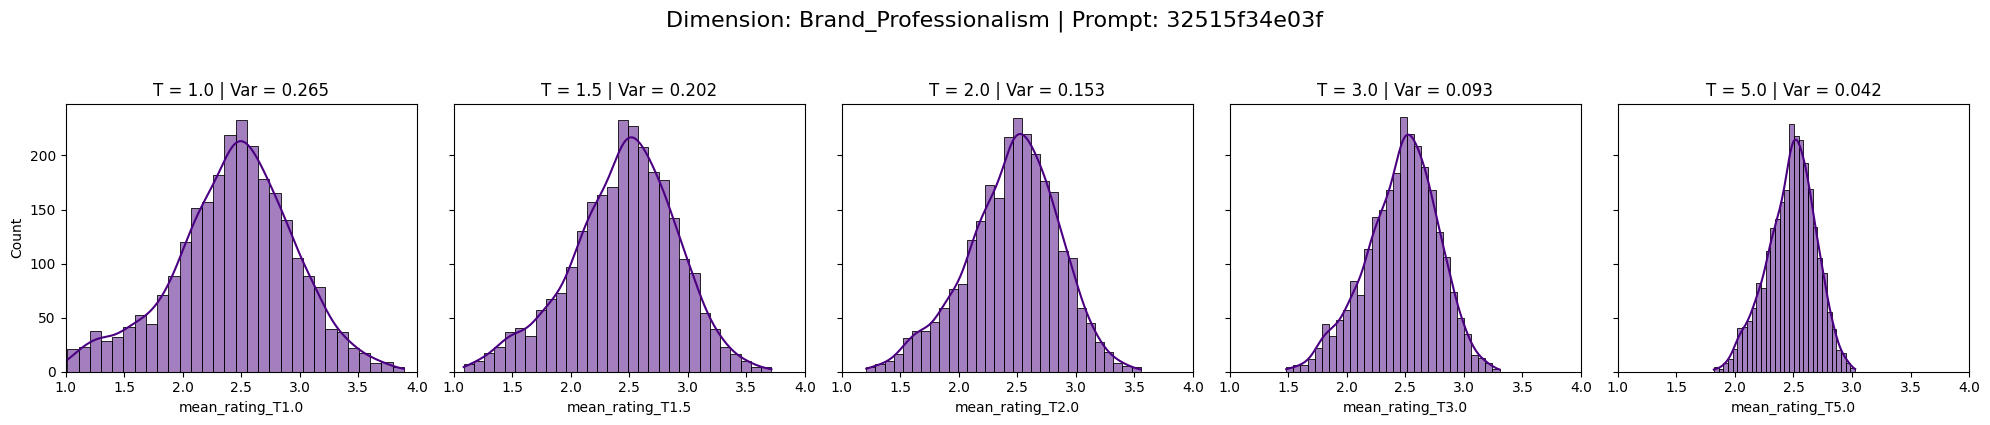

In [ ]:
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setup and Computation (Do this once for the whole DF)
weights = np.array([1.0, 2.0, 3.0, 4.0])
temperatures = [1.0, 1.5, 2.0, 3.0, 5.0]


def compute_temp_scaled_ev(logits_nested_list, T):
    logits = np.array(logits_nested_list[0], dtype=float)
    scaled_logits = logits / T
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits))
    probs = exp_logits / np.sum(exp_logits)
    weights_array = np.arange(len(probs)) + 1
    return np.sum(probs * weights_array)


print("Computing temperature-scaled columns...")
for T in temperatures:
    col_name = f'mean_rating_T{T}'
    final_df[col_name] = final_df['sorted_logits'].apply(
        lambda x: compute_temp_scaled_ev(x, T)
    )

# 2. Generate and Store the Plots in a Dictionary
print("Generating plots for the dashboard...")
plot_dict = {}

# Assuming 'dimension_name' is the "rating" category from your widget
groups = final_df.groupby(['dimension_name', 'prompt_id'])

for (dim, pid), group_df in groups:
    # Create the figure
    fig, axes = plt.subplots(1, len(temperatures),
                             figsize=(20, 4), sharey=True)
    fig.suptitle(f"Dimension: {dim} | Prompt: {pid}", fontsize=16, y=1.05)

    for i, T in enumerate(temperatures):
        col = f'mean_rating_T{T}'

        # Safely handle variance if the group is too small
        var_val = group_df[col].var() if len(group_df) > 1 else 0.0
        mean_val = group_df[col].mean()

        sns.histplot(group_df[col], bins=30, kde=True,
                     ax=axes[i], color='indigo')
        axes[i].set_title(f"T = {T} | Var = {var_val:.3f}")
        axes[i].set_xlim(1, 4)

    plt.tight_layout()
    # Crucial: prevents the plot from dumping to the cell immediately
    plt.close(fig)

    # Store the figure object in the dictionary using the tuple key your widget expects
    plot_dict[(dim, pid)] = fig

print("✓ Dashboard ready!")

# 3. The Interactive Widget (Adapted directly from your code)


def interactive_plot_selector(data_dict, description="Select option:"):
    # label -> value pairs; k[0] is dimension, k[1] is prompt_id
    options = [(f"prompt {k[1]} | {k[0]}", k) for k in data_dict.keys()]

    dropdown = widgets.Dropdown(
        options=options,
        description=description,
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='400px')
    )

    def update_plot(change):
        clear_output(wait=True)
        display(dropdown)
        # Displaying a matplotlib Figure object renders it natively in Jupyter
        display(data_dict[change.new])

    dropdown.observe(update_plot, names='value')

    # Render the initial state
    display(dropdown)
    display(data_dict[dropdown.value])


# 4. Launch the dashboard!
interactive_plot_selector(plot_dict, description="Select Rating & Prompt:")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure these map exactly to the order of your sorted_logits!
# We assume the logits correspond to tokens for ratings 1, 2, 3, 4.
weights = np.array([1.0, 2.0, 3.0, 4.0])

# The temperature scales we want to test
temperatures = [1.0, 1.5, 2.0, 3.0, 5.0]


def compute_temp_scaled_ev(logits_nested_list, T):
    """
    Safely calculates temperature-scaled expected values from a nested logit list.
    """
    # 1. Extract the inner list (logits for the first generated token)
    logits = np.array(logits_nested_list[0], dtype=float)

    # 2. Apply Temperature
    scaled_logits = logits / T

    # 3. Stable Softmax (subtract max to prevent overflow)
    exp_logits = np.exp(scaled_logits - np.max(scaled_logits))
    probs = exp_logits / np.sum(exp_logits)

    # 4. Calculate Expected Value
    weights_array = np.arange(len(probs))+1
    return np.sum(probs * weights_array)


# Apply the function to create our new columns
for T in temperatures:
    col_name = f'mean_rating_T{T}'
    final_df[col_name] = final_df['sorted_logits'].apply(
        lambda x: compute_temp_scaled_ev(x, T)
    )

print("✓ Temperature-scaled columns created successfully.")

C:\Users\Wouter Barter\AppData\Local\Temp\ipykernel_38792\2683194351.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df[col_name] = final_df['sorted_logits'].apply(


✓ Temperature-scaled columns created successfully.


--- OLS Leverage Diagnostics (Variance Check) ---
T=1.0 | Variance: 0.5406 | Mean: 2.49
T=1.5 | Variance: 0.4439 | Mean: 2.50
T=2.0 | Variance: 0.3801 | Mean: 2.50
T=3.0 | Variance: 0.2970 | Mean: 2.51
T=5.0 | Variance: 0.1961 | Mean: 2.52


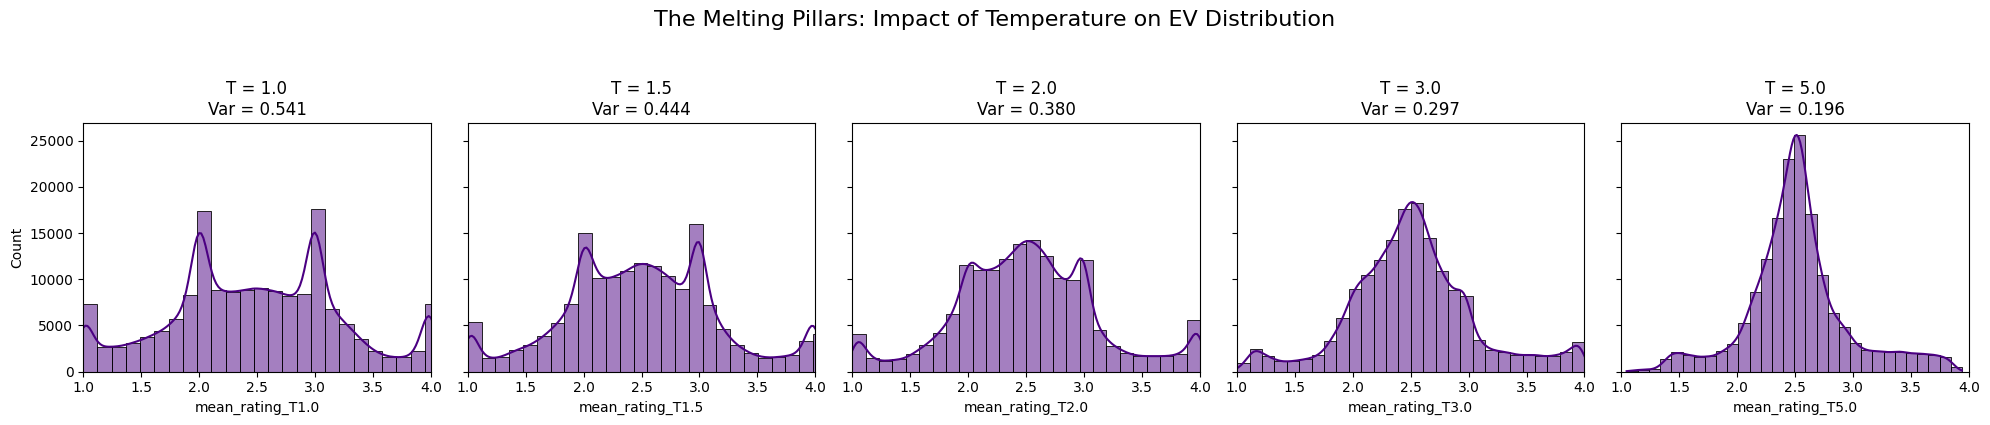

In [ ]:
fig, axes = plt.subplots(1, len(temperatures), figsize=(20, 4), sharey=True)
fig.suptitle(
    f"The Melting Pillars: Impact of Temperature on EV Distribution", fontsize=16, y=1.05)

print("--- OLS Leverage Diagnostics (Variance Check) ---")

for i, T in enumerate(temperatures):
    col = f'mean_rating_T{T}'
    var_val = final_df[col].var()
    mean_val = final_df[col].mean()

    print(f"T={T} | Variance: {var_val:.4f} | Mean: {mean_val:.2f}")

    sns.histplot(final_df[col], bins=30, kde=True, ax=axes[i], color='indigo')
    axes[i].set_title(f"T = {T}\nVar = {var_val:.3f}")
    axes[i].set_xlim(1, 4)

plt.tight_layout()
plt.show()

In [ ]:
final_df.columns

Index(['applicants_applications_count', 'content_types', 'deal_id',
       'main_image', 'min_social_media_followers', 'deal_tags', 'live_since',
       'first_application_at', 'last_application_at', 'company_locations',
       ...
       'mode_rating', 'scale_size', 'entropy', 'normalized_entropy',
       'first_content_type', 'mean_rating_T1.0', 'mean_rating_T1.5',
       'mean_rating_T2.0', 'mean_rating_T3.0', 'mean_rating_T5.0'],
      dtype='object', length=102)

--- OLS Leverage Diagnostics ---
Task_Clarity:
  Mean: 2.26 | Variance: 0.371 | Min-Max: 1.00 - 3.96

Brand_Professionalism:
  Mean: 2.44 | Variance: 0.265 | Min-Max: 1.01 - 3.89

Hook_Strength:
  Mean: 2.13 | Variance: 0.119 | Min-Max: 1.01 - 3.50



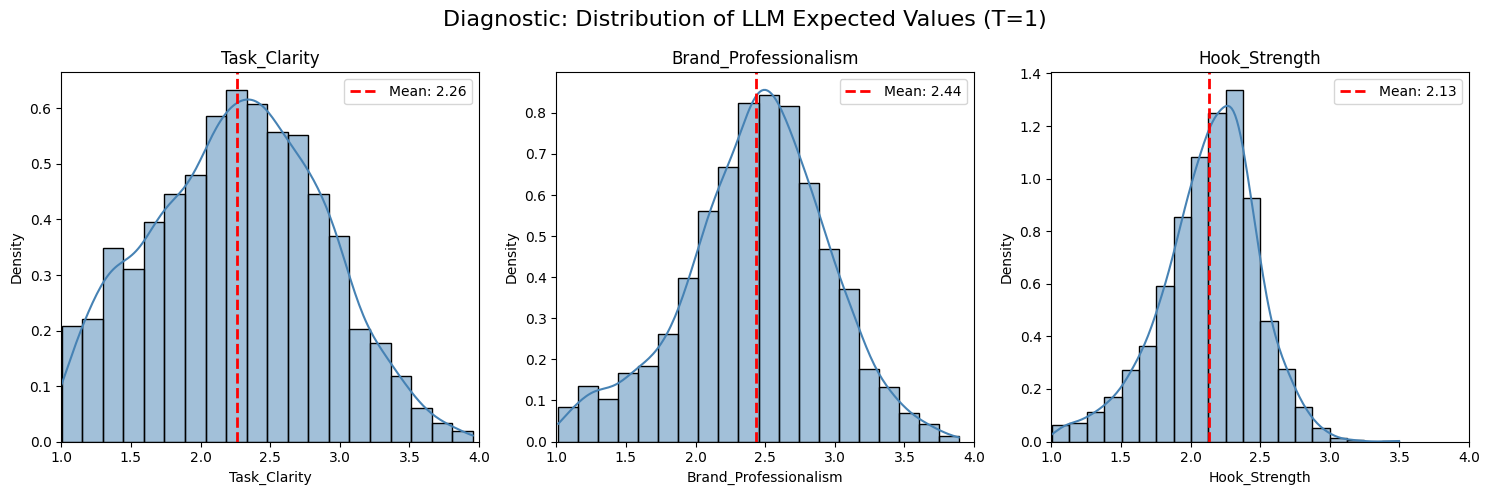

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

wide_df = final_df[final_df['prompt_id'] == '32515f34e03f'].pivot(
    index='input_id', columns='dimension_name', values='mean_rating')

# Assuming your wide_df contains the dimensions as columns.
# Replace these with your exact column names if they differ!
score_cols = ['Task_Clarity', 'Brand_Professionalism', 'Hook_Strength']

# Set up the plotting grid
fig, axes = plt.subplots(1, len(score_cols), figsize=(15, 5), sharey=False)
fig.suptitle(
    "Diagnostic: Distribution of LLM Expected Values (T=1)", fontsize=16)

print("--- OLS Leverage Diagnostics ---")

for i, col in enumerate(score_cols):
    # 1. Calculate and print the critical variance metrics
    col_var = wide_df[col].var()
    col_mean = wide_df[col].mean()
    print(f"{col}:")
    print(
        f"  Mean: {col_mean:.2f} | Variance: {col_var:.3f} | Min-Max: {wide_df[col].min():.2f} - {wide_df[col].max():.2f}\n")

    # 2. Plot the distribution
    sns.histplot(wide_df[col], bins=20, kde=True,
                 ax=axes[i], color='steelblue', stat='density')

    # 3. Add a vertical line for the mean to anchor the visual
    axes[i].axvline(col_mean, color='red', linestyle='dashed',
                    linewidth=2, label=f'Mean: {col_mean:.2f}')
    axes[i].set_title(col)
    axes[i].set_xlim(1, 4)  # Lock x-axis to our true 1-4 scale
    axes[i].legend()

plt.tight_layout()
plt.show()

-----------

# Rest

## Recoding physical liquidity vars
- I recoded the physical active vars to decrease the bucket granularity, but I opted to drop the physical deals altoghether instead

In [ ]:
# active_creators_cols = ['log_online_active_0_7d',
#        'log_online_active_7_30d', 'log_phys_active_0_7d_0_10km',
#        'log_phys_active_0_7d_10_20km', 'log_phys_active_0_7d_20_50km',
#        'log_phys_active_7_30d_0_10km', 'log_phys_active_7_30d_10_20km',
#        'log_phys_active_7_30d_20_50km']

In [ ]:
import numpy as np

# 1. Rebuild the Hyper-Local bin (0-10km, all 30 days)
df['phys_active_0_30d_0_10km'] = (
    df['phys_active_0_7d_0_10km'] +
    df['phys_active_7_30d_0_10km']
)
df['log_phys_active_0_30d_0_10km'] = np.log1p(df['phys_active_0_30d_0_10km'])

# 2. Rebuild the Local bin (10-20km, all 30 days)
df['phys_active_0_30d_10_20km'] = (
    df['phys_active_0_7d_10_20km'] +
    df['phys_active_7_30d_10_20km']
)
df['log_phys_active_0_30d_10_20km'] = np.log1p(df['phys_active_0_30d_10_20km'])

# 3. Rebuild the Regional bin (20-50km, all 30 days)
df['phys_active_0_30d_20_50km'] = (
    df['phys_active_0_7d_20_50km'] +
    df['phys_active_7_30d_20_50km']
)
df['log_phys_active_0_30d_20_50km'] = np.log1p(df['phys_active_0_30d_20_50km'])

In [ ]:
# The newly consolidated list (5 features instead of 8)
active_creators_cols = [
    'log_online_active_0_7d',
    'log_online_active_7_30d',
    'log_phys_active_0_30d_0_10km',
    'log_phys_active_0_30d_10_20km',
    'log_phys_active_0_30d_20_50km'
]

# Ensure we don't accidentally append duplicates if you run the cell twice
CONTINUOUS = ['competitor_density']
# CONTINUOUS = [col for col in CONTINUOUS if col not in active_creators_cols]
CONTINUOUS += active_creators_cols


# 1. Isolate Physical Deals
df_phys = df[df['deal_type'] == 'physical'].copy()

# 2. Define strictly physical features (Drop online!)
phys_continuous = [
    'competitor_density',
    'log_phys_active_0_30d_0_10km',
    'log_phys_active_0_30d_10_20km',
    'log_phys_active_0_30d_20_50km'
]

# 3. Check if market_scope even has variance in physical deals
# (If all physical deals are in NLD, drop market_scope entirely!)
df_phys['market_scope'].value_counts()

# 4. Run the isolated model
ols_results = ols_runner.run_baseline_model(
    df=df_phys,
    cat_vars=[],  # Only include if value_counts shows distinct categories
    bin_vars=BINARIES,
    num_vars=phys_continuous,
    label="Isolated_Physical_OLS"
)

ValueError: zero-size array to reduction operation maximum which has no identity

## Other rest

In [ ]:
og_df.consolidated_categories.value_counts()

consolidated_categories
Other                        381
Lifestyle_Luxury             239
Beauty_UGC                   203
Fashion_Lifestyle            193
Activities_Sport             116
Cooking_Food                 110
Tech_UGC                     108
Mom_UGC                      107
Lifestyle_UGC                100
Food_Lifestyle                92
Animals_Lifestyle             88
Lifestyle_Nightlife           81
Food_Vegan                    76
Lifestyle_Travel              75
Drinks_Food                   70
Entertainment_Gaming          65
Lifestyle                     58
Lifestyle_Vegan               58
Cooking_Vegan                 56
Entertainment_Music           55
Drinks_Lifestyle              54
Finance_Lifestyle             53
Lifestyle_Photography         50
Cars_Lifestyle                49
Entertainment_Experiences     46
Beauty_Fashion                45
Experiences_Food              38
Entertainment_Lifestyle       36
Fashion_Mom                   31
Activities_Lifestyl

In [ ]:
subset_categories = ['Lifestyle_Luxury', 'Beauty_UGC', 'Fashion_Lifestyle']

In [ ]:
og_df['consolidated_categories'].isin(subset_categories).sum()

np.int64(635)

In [ ]:
subset_categories = ['Lifestyle', 'Lifestyle_Luxury',
                     'Beauty_UGC', 'Beauty_Fashion']

runner = create_regression_runner(
    target_col='log_apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='ols'
)

runner.run_baseline_model(
    df=og_df[og_df['consolidated_categories'].isin(subset_categories)],
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="baseline_model_OLS"
)

runner.run_regression(df=final_df[final_df['consolidated_categories'].isin(subset_categories)],
                      cat_vars=CATEGORICALS,
                      bin_vars=BINARIES,
                      num_vars=CONTINUOUS,
                      predictor_name='mean_rating')

interactive_regression_results_selector(runner.results)

✓ Baseline model fitted: 545.0 observations, AIC=1463.66


Dropdown(description='Select option:', layout=Layout(width='400px'), options=('baseline_model_OLS', "('Qwen/Qw…

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     log_apps_after_7_days   R-squared:                       0.342
Model:                               OLS   Adj. R-squared:                  0.331
Method:                    Least Squares   F-statistic:                     21.67
Date:                   Fri, 13 Mar 2026   Prob (F-statistic):           1.46e-27
Time:                           10:53:23   Log-Likelihood:                -721.83
No. Observations:                    545   AIC:                             1464.
Df Residuals:                        535   BIC:                             1507.
Df Model:                              9                                         
Covariance Type:                 cluster                                         
============================================================================================================
                                               coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------
const                                        1.7235      0.530      3.254      0.001       0.681       2.766
competitor_density                           0.0174      0.028      0.613      0.540      -0.038       0.073
log_physical_active_creators_7d_50km         0.2727      0.100      2.717      0.007       0.075       0.470
log_online_eligible_last_week                0.2506      0.080      3.121      0.002       0.093       0.409
market_scope_Tier2_NLD_only                 -0.2669      0.123     -2.164      0.031      -0.510      -0.024
market_scope_Tier3_BEL_Only                 -0.4748      0.265     -1.794      0.074      -0.996       0.046
market_scope_Tier4_Germany                  -0.9351      0.246     -3.798      0.000      -1.420      -0.450
consolidated_categories_Beauty_UGC          -0.2572      0.189     -1.363      0.174      -0.629       0.114
consolidated_categories_Lifestyle            0.0656      0.222      0.296      0.767      -0.371       0.502
consolidated_categories_Lifestyle_Luxury    -0.0373      0.190     -0.196      0.845      -0.412       0.337
==============================================================================
Omnibus:                       34.447   Durbin-Watson:                   1.806
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               44.160
Skew:                          -0.542   Prob(JB):                     2.57e-10
Kurtosis:                       3.878   Cond. No.                         76.4
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [ ]:
qwen3_adjr2 = (0.404 - 0.352) / 0.352
qwen35_adjr2 = (0.420 - 0.361) / 0.361
llama_adjr2 = (0.371-0.348) / 0.348

print(f"qwen3 percent increase in adjr2: {qwen3_adjr2}")
print(f"qwen3.5 percent increase in adjr2: {qwen35_adjr2}")
print(f"llama percent increase in adjr2: {llama_adjr2}")

qwen3 percent increase in adjr2: 0.14772727272727287
qwen3.5 percent increase in adjr2: 0.1634349030470914
llama percent increase in adjr2: 0.06609195402298856
